# Hybrid Weather Forecasting with ARIMA, SARIMA and LSTM

**A leakage-free, multi-horizon comparison of statistical, deep-learning and hybrid models for daily temperature forecasting on the Jena Climate benchmark (2009 – 2016)**

*Rajarshi Chakraborty · 6th-Semester Project*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/therajarshichakraborty/Final-Year-Project/blob/main/final_stock_market.ipynb)

---

> **Abstract.** Day-to-day weather contains *linear* structure (a strong annual cycle and short-term persistence) and *non-linear*, multivariate structure (fronts, air-mass advection, humidity–radiation feedbacks). Box–Jenkins models capture the first; recurrent neural networks can learn the second but need more data and become unstable when iterated far ahead. This notebook builds seven forecasters of daily mean air temperature and compares them rigorously: two naïve baselines, **ARIMA**, **SARIMA** with Fourier seasonality, a multi-task **LSTM** ensemble, and two **hybrids**. The first hybrid is a SARIMA model whose errors are learned by an LSTM; the second is an optimally weighted SARIMA–LSTM ensemble. All models are evaluated under a single rolling-origin protocol on an untouched test year, at horizons from 1 to 90 days. The evaluation uses RMSE, MAE, MAPE and R², scale-free skill scores, Diebold–Mariano significance tests and calibration checks of 95 % prediction intervals. The notebook ends with 90-day out-of-sample forecasts and a research summary that is generated from the numbers computed in this run.

### Contents

| § | Section | What happens |
|:-:|---|---|
| 1 | Setup | libraries, configuration, reproducibility, figure style |
| 2 | Data acquisition | automatic download of the Jena Climate archive (≈ 13 MB, no login) |
| 3 | Data quality & preprocessing | duplicates, sentinel codes, gaps, wind vectors, daily resampling, imputation |
| 4 | Exploratory analysis | eight-year weather overview, correlation structure |
| 5 | Time-series diagnostics | STL decomposition, ADF / KPSS stationarity tests, ACF / PACF |
| 6 | Experimental design | chronological split, rolling-origin protocol, metrics, baselines |
| 7 | ARIMA | AIC order search, estimation, exact multi-horizon forecasts |
| 8 | SARIMA | Fourier seasonality, order search, impulse response |
| 9 | LSTM | multi-task recurrent network, seed ensemble, recursive forecasting |
| 10 | Hybrid models | SARIMA + LSTM residual learner · optimal-weight ensemble |
| 11 | Evaluation | accuracy tables, significance tests, horizon analysis, residual diagnostics |
| 12 | Uncertainty quantification | analytic and conformal 95 % prediction intervals, calibration |
| 13 | 90-day future forecast | out-of-sample outlook with prediction intervals |
| 14 | Research summary | methodology, results, contributions, limitations, references |
| 15 | Export | 300-dpi figures, CSV tables, trained models |

**How to run.** In Google Colab choose *Runtime → Run all*. There is nothing to upload and no API key to enter: the dataset downloads automatically from Google Cloud Storage, with an AWS mirror as fallback. The notebook requests a GPU runtime, where it finishes in a few minutes. A CPU-only runtime also works but is slower, roughly 10–15 minutes. Every number in the closing summary is computed in that run, so the text always matches the results.

**Methodology at a glance**
```
 10-minute station record (420 k rows, 14 variables)
   └─ clean: de-duplicate · sentinel codes · physical QC · wind → (u, v) vectors
      └─ resample to daily means / extremes · flag low-coverage days · time-interpolate
         └─ chronological split:  2009–2014 train  │  2015 validation  │  2016 test
            ├─ baselines ........ persistence · climatology
            ├─ statistical ...... ARIMA (AIC search) · SARIMA (Fourier seasonality)
            ├─ deep learning .... multi-task LSTM ensemble (recursive multi-step)
            └─ hybrids .......... Hybrid-R = SARIMA + LSTM residual learner
                                  Hybrid-E = optimal per-horizon SARIMA/LSTM weights
               └─ rolling-origin evaluation, horizons 1–90 days
                  └─ metrics · Diebold–Mariano tests · interval calibration · 90-day outlook
```

### Research questions

* **RQ1 – Accuracy.** Do hybrid models forecast tomorrow's temperature more accurately than their statistical and neural components, and is the improvement statistically significant?
* **RQ2 – Horizon.** How does forecast skill decay from 1 to 90 days ahead, and which model is most reliable at each lead time?
* **RQ3 – Uncertainty.** Are the 95 % prediction intervals *calibrated*, meaning they contain the truth about 95 % of the time on unseen data?

*Project context.* This work extends the earlier stock-market BiLSTM project. That project's key lessons — chronological splits, scalers fitted on training data only, and the danger of recursive error accumulation — are carried over. This project adds classical time-series models, hybridisation, significance testing and uncertainty quantification on a physical (meteorological) system.

## 1 · Setup
All libraries used here are pre-installed on Google Colab. The configuration cell (1.2) is the only place where settings need to change.

In [1]:
# ── 1.1  Libraries ───────────────────────────────────────────────────────────
import os, sys, json, time, shutil, zipfile, logging, warnings, urllib.request
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")       # hide TensorFlow's C++ start-up messages
logging.getLogger().addHandler(logging.NullHandler())     # keeps TensorFlow from attaching its own console logger
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import PolyCollection
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima_process import arma2ma
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow import keras

# Placed after the imports on purpose: statsmodels re-enables its own warnings when it is imported.
warnings.filterwarnings("ignore")            # convergence notices from the order search, KPSS table bounds
IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_START = time.time()
gpus = tf.config.list_physical_devices("GPU")
print(f"Python {sys.version.split()[0]} · NumPy {np.__version__} · pandas {pd.__version__} · "
      f"statsmodels {statsmodels.__version__} · TensorFlow {tf.__version__}")
print(f"Accelerator: {'GPU (' + gpus[0].name + ')' if gpus else 'CPU — sufficient, a GPU runtime is just faster'}")

Python 3.11.9 · NumPy 2.4.6 · pandas 3.0.3 · statsmodels 0.14.6 · TensorFlow 2.21.0
Accelerator: CPU — sufficient, a GPU runtime is just faster


In [2]:
# ── 1.2  Experiment configuration (the only cell you need to edit) ──────────
SEED              = 42
DATA_DIR          = Path("data")
OUT_DIR           = Path("outputs")
FIG_DIR           = OUT_DIR / "figures"

TRAIN_END         = "2014-12-31"   # 2009–2014 → training   (parameter estimation)
VAL_END           = "2015-12-31"   # 2015      → validation (early stopping, ensemble weights, interval calibration)
                                   # 2016      → test year  (used exactly once, for the final evaluation)
FORECAST_HORIZON  = 90             # days ahead; any value from 30 to 90
LOOKBACK          = 30             # days of history fed to the LSTM
N_ENSEMBLE        = 3              # independently seeded networks per neural model (1 = quickest run)
MAX_EPOCHS        = 300            # upper bound only; early stopping chooses the actual number
BATCH_SIZE        = 32
ALPHA             = 0.05           # 1 − ALPHA = 95 % prediction intervals
MIN_DAY_COVERAGE  = 0.50           # a day needs ≥ 50 % of its 144 ten-minute readings to be trusted

assert 30 <= FORECAST_HORIZON <= 90, "FORECAST_HORIZON must lie between 30 and 90 days"
H = FORECAST_HORIZON
for folder in (DATA_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)
keras.utils.set_random_seed(SEED)   # seeds Python, NumPy and TensorFlow together

In [3]:
# ── 1.3  Figure style ────────────────────────────────────────────────────────
# Model colours are fixed and colour-blind-checked: every adjacent pair stays distinguishable under
# protanopia/deuteranopia (ΔE ≥ 9). Baselines are neutral greys and observations are near-black, so
# the eye goes to the competing models. Each model keeps the same colour in every figure.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
MODEL_ORDER = ["Persistence", "Climatology", "ARIMA", "SARIMA", "LSTM", "Hybrid-R", "Hybrid-E"]
FAMILY = {"Persistence": "Baseline", "Climatology": "Baseline", "ARIMA": "Statistical", "SARIMA": "Statistical",
          "LSTM": "Deep learning", "Hybrid-R": "Hybrid", "Hybrid-E": "Hybrid"}
COLORS = {"Actual": INK, "Persistence": MUTED, "Climatology": INK_2, "Hybrid-R": "#2a78d6",
          "SARIMA": "#eb6834", "LSTM": "#1baf7a", "ARIMA": "#eda100", "Hybrid-E": "#e87ba4"}
LINESTYLES = {"Persistence": (0, (5, 2)), "Climatology": (0, (1, 1.6))}     # reference lines: dashed / dotted
DIVERGING = LinearSegmentedColormap.from_list("blue_grey_red", ["#2a78d6", "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "figure.constrained_layout.use": True,
    "font.size": 10.5, "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 8, "axes.labelsize": 10, "axes.labelcolor": INK_2, "axes.edgecolor": AXIS,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.7, "grid.linestyle": "-",
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK, "axes.titlecolor": INK, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
})

def finish(fig, number, title, filename):
    """Number the figure, save a 300-dpi PNG for the report / paper, and display it."""
    fig.suptitle(f"Fig. {number} · {title}", x=0.01, ha="left", fontsize=13.5, fontweight="semibold")
    fig.savefig(FIG_DIR / f"fig{number:02d}_{filename}.png")
    plt.show()

def show_table(df, number, caption, fmt=None, low=(), high=(), index=True):
    """Display a numbered table; the best value of each `low` / `high` column is shown in bold."""
    styler = df.style.format(fmt or "{:.3f}", na_rep="—").set_caption(f"Table {number} · {caption}")
    if low:
        styler = styler.highlight_min(subset=list(low), props="font-weight:bold; color:#0b0b0b;")
    if high:
        styler = styler.highlight_max(subset=list(high), props="font-weight:bold; color:#0b0b0b;")
    if not index:
        styler = styler.hide(axis="index")
    display(styler.set_table_styles([{"selector": "caption",
                                      "props": "caption-side: top; font-weight: 600; font-size: 1.05em; text-align: left;"}]))

## 2 · Data acquisition

**Dataset — Jena Climate, 2009–2016.** These readings were recorded every 10 minutes by the weather station of the Max Planck Institute for Biogeochemistry in Jena, Germany. TensorFlow/Keras distributes the archive as a standard time-series benchmark (Chollet, 2021). It is public, needs no account, and has about 420 000 records, enough for both statistical and deep-learning models.

| Variable | Description | Unit | Role |
|---|---|---|---|
| `T` | air temperature | °C | **forecast target** (daily mean) and input |
| `Tdew` | dew-point temperature | °C | input |
| `rh` | relative humidity | % | input |
| `p` | air pressure | hPa | input |
| `VPdef` | vapour-pressure deficit | hPa | input |
| `wv`, `max. wv` | mean wind speed, maximum gust | m s⁻¹ | input |
| `wd` | wind direction | degrees | converted to wind vector (u, v) |

The archive also contains six columns that are near-exact functions of the variables above: potential temperature, saturation and actual vapour pressure, specific humidity, water-vapour concentration and air density. They are excluded to avoid multicollinearity.

In [4]:
# ── 2.1  Download (cached after the first run) ──────────────────────────────
MIRRORS = [
    "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",   # Google
    "https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip",                       # AWS fallback
]

def download_dataset(destination: Path) -> Path:
    """Fetch the Jena Climate archive once, trying each public mirror until one succeeds."""
    if destination.exists() and zipfile.is_zipfile(destination):
        print(f"Using cached archive: {destination.as_posix()}")
        return destination
    for url in MIRRORS:
        try:
            print(f"Downloading from {url.split('/')[2]} ... ", end="")
            urllib.request.urlretrieve(url, destination)
            if zipfile.is_zipfile(destination):
                print(f"done ({destination.stat().st_size / 1e6:.1f} MB)")
                return destination
            print("not a valid zip archive")
        except Exception as error:
            print(f"failed ({type(error).__name__})")
    raise RuntimeError("Every mirror failed - please check the runtime's internet connection.")

archive = download_dataset(DATA_DIR / "jena_climate_2009_2016.csv.zip")
with zipfile.ZipFile(archive) as zf:
    csv_member = next(name for name in zf.namelist() if name.endswith(".csv"))
    raw = pd.read_csv(zf.open(csv_member))

print(f"Raw record: {len(raw):,} rows × {raw.shape[1]} columns at 10-minute resolution")
raw.head()

done (13.6 MB)


Raw record: 420,551 rows × 15 columns at 10-minute resolution


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3 · Data quality & preprocessing

Raw sensor data is never analysis-ready. Each step below fixes a specific, documented defect:

1. **Duplicate timestamps.** The same 10-minute slot logged twice is removed, keeping the first record.
2. **Sentinel codes.** The logger writes `−9999` when a wind sensor fails. Left in place, it would shift a daily mean by hundreds of m s⁻¹, so it is marked as missing.
3. **Physical range checks.** Physically impossible readings are marked as missing (for example humidity above 100 % or pressure outside 900–1100 hPa).
4. **Wind vectors.** Direction is circular: 350° and 10° are neighbours, yet their arithmetic mean is 180°. Wind is therefore converted to east–west (*u*) and north–south (*v*) components before averaging.
5. **Daily resampling.** 10-minute readings become daily means. Temperature extremes are kept as daily minimum and maximum, and wind gusts as the daily maximum.
6. **Coverage rule.** A "daily mean" computed from a few hours of data is biased; a few night readings, for example, would make the day look cold. Days with less than 50 % of their 144 readings are treated as missing and **time-interpolated** from neighbouring days.

In [5]:
# ── 3.1  Clean the 10-minute record ─────────────────────────────────────────
RENAME = {"Date Time": "datetime", "T (degC)": "T", "Tdew (degC)": "Tdew", "rh (%)": "rh", "p (mbar)": "p",
          "VPdef (mbar)": "VPdef", "wv (m/s)": "wv", "max. wv (m/s)": "wv_max", "wd (deg)": "wd"}
df = raw.rename(columns=RENAME)[list(RENAME.values())].copy()
df["datetime"] = pd.to_datetime(df["datetime"], format="%d.%m.%Y %H:%M:%S")

n_duplicates = int(df["datetime"].duplicated().sum())
df = df.drop_duplicates("datetime").set_index("datetime").sort_index()

expected_stamps = pd.date_range(df.index.min(), df.index.max(), freq="10min")
n_missing_stamps = len(expected_stamps.difference(df.index))

sentinel = df.eq(-9999.0)
n_sentinel = int(sentinel.to_numpy().sum())
df = df.mask(sentinel)

PHYSICAL_LIMITS = {"T": (-40, 50), "Tdew": (-50, 40), "rh": (0, 100), "p": (900, 1100),
                   "VPdef": (0, 100), "wv": (0, 60), "wv_max": (0, 80), "wd": (0, 360)}
implausible = pd.DataFrame({col: df[col].notna() & ~df[col].between(lo, hi)
                            for col, (lo, hi) in PHYSICAL_LIMITS.items()})
n_implausible = int(implausible.to_numpy().sum())
df = df.mask(implausible)

# Wind speed + direction → vector components (meteorological convention: direction the wind blows FROM)
direction = np.deg2rad(df["wd"])
df["u"] = -df["wv"] * np.sin(direction)
df["v"] = -df["wv"] * np.cos(direction)

In [6]:
# ── 3.2  Resample to daily resolution and impute low-coverage days ───────────
day = df.resample("D")
daily = pd.DataFrame({
    "T": day["T"].mean(), "Tmin": day["T"].min(), "Tmax": day["T"].max(),
    "Tdew": day["Tdew"].mean(), "rh": day["rh"].mean(), "p": day["p"].mean(), "VPdef": day["VPdef"].mean(),
    "wv": day["wv"].mean(), "wv_max": day["wv_max"].max(), "u": day["u"].mean(), "v": day["v"].mean(),
})
coverage = day["T"].count() / 144                  # share of the 144 ten-minute slots that were recorded

daily = daily.loc[:"2016-12-31"]                   # the archive ends with one reading on 2017-01-01
coverage = coverage.loc[daily.index]
low_coverage = coverage.index[coverage < MIN_DAY_COVERAGE]
daily.loc[low_coverage] = np.nan
daily = daily.interpolate(method="time").asfreq("D")
assert daily.notna().all().all(), "unexpected missing values after imputation"

WEATHER_VARS = list(daily.columns)                 # 11 daily variables; the target "T" is first
LABELS = {"T": "Mean temperature", "Tmin": "Min temperature", "Tmax": "Max temperature", "Tdew": "Dew point",
          "rh": "Relative humidity", "p": "Pressure", "VPdef": "Vapour-pressure deficit", "wv": "Wind speed",
          "wv_max": "Max gust", "u": "Wind u (east–west)", "v": "Wind v (north–south)"}

quality = pd.DataFrame([
    ("Duplicate timestamps", f"{n_duplicates:,}", "removed (first record kept)"),
    ("Missing 10-minute timestamps", f"{n_missing_stamps:,} ({n_missing_stamps / len(expected_stamps):.2%})",
     "absorbed by daily aggregation"),
    ("Sentinel values (−9999)", f"{n_sentinel:,}", "set to missing"),
    ("Physically implausible readings", f"{n_implausible:,}", "set to missing"),
    (f"Days below {MIN_DAY_COVERAGE:.0%} coverage",
     f"{len(low_coverage)}: " + ", ".join(f"{d:%d %b %Y}" for d in low_coverage), "time-interpolated"),
    ("Analysis-ready daily series", f"{len(daily):,} days · {daily.index[0]:%d %b %Y} → {daily.index[-1]:%d %b %Y}",
     "0 missing values"),
], columns=["Check", "Finding", "Action"])
show_table(quality, 1, "Data-quality audit of the raw 10-minute record", fmt="{}", index=False)

Check,Finding,Action
Duplicate timestamps,327,removed (first record kept)
Missing 10-minute timestamps,544 (0.13%),absorbed by daily aggregation
Sentinel values (−9999),38,set to missing
Physically implausible readings,0,set to missing
Days below 50% coverage,"4: 25 Oct 2016, 26 Oct 2016, 27 Oct 2016, 28 Oct 2016",time-interpolated
Analysis-ready daily series,"2,922 days · 01 Jan 2009 → 31 Dec 2016",0 missing values


## 4 · Exploratory data analysis

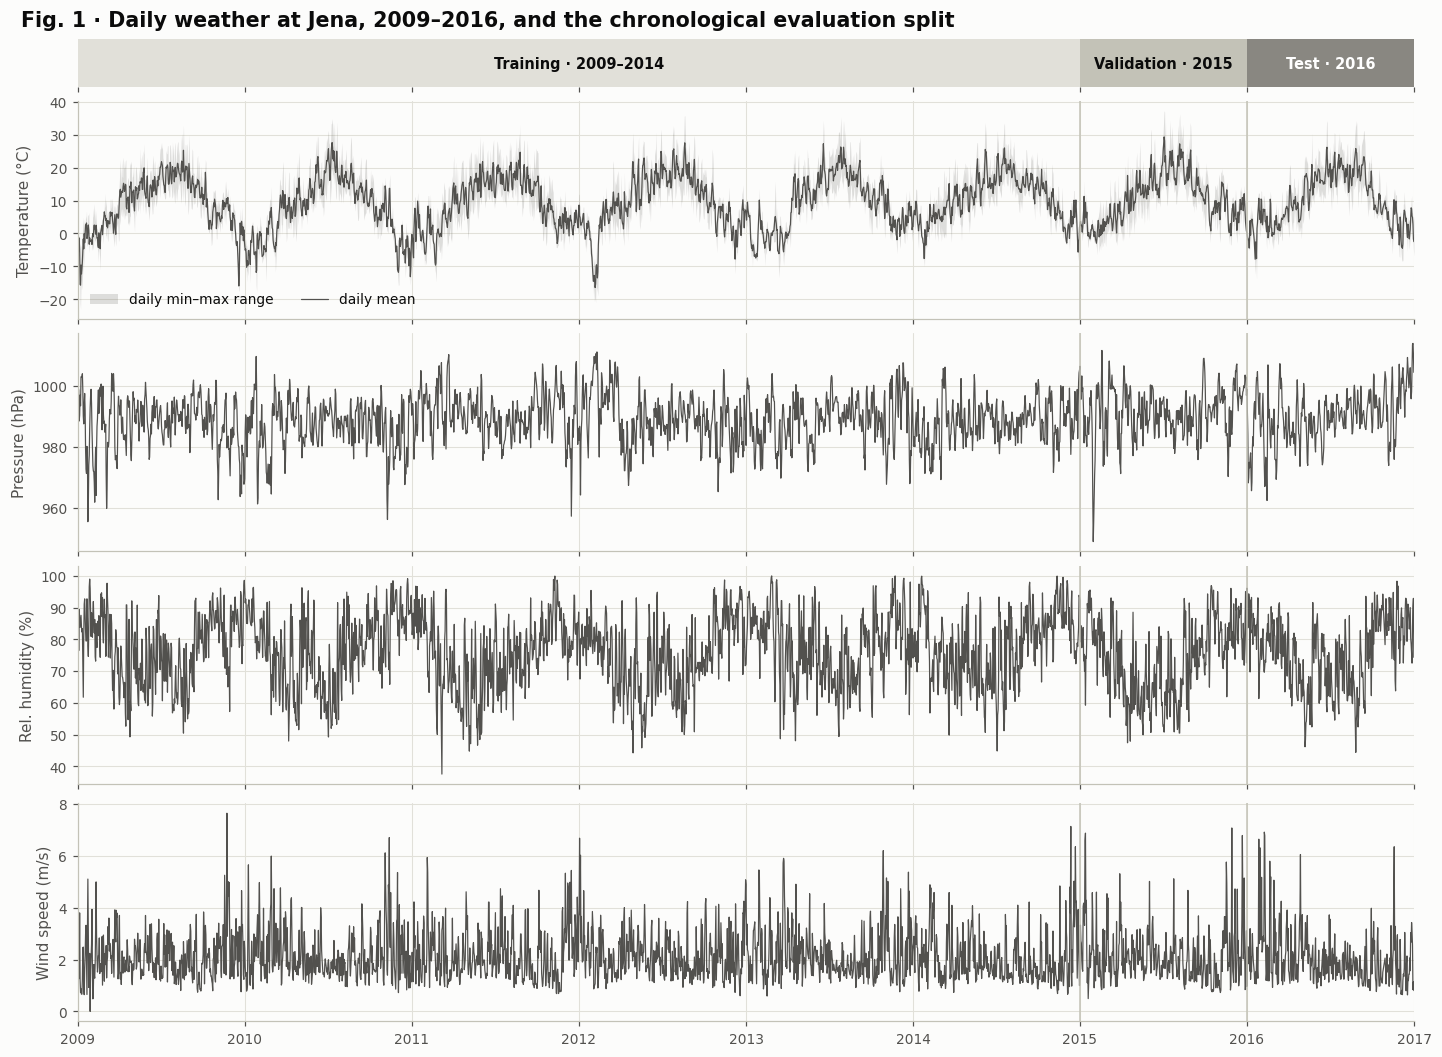

In [7]:
# ── 4.1  Fig. 1 — eight years of daily weather and the evaluation split ─────
split_edges = [daily.index[0], pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1),
               pd.Timestamp(VAL_END) + pd.Timedelta(days=1), daily.index[-1] + pd.Timedelta(days=1)]
split_names = ["Training · 2009–2014", "Validation · 2015", "Test · 2016"]
panels = [("T", "Temperature (°C)"), ("p", "Pressure (hPa)"), ("rh", "Rel. humidity (%)"), ("wv", "Wind speed (m/s)")]

fig, axes = plt.subplots(len(panels) + 1, 1, figsize=(13, 9.5), sharex=True,
                         gridspec_kw={"height_ratios": [0.22] + [1] * len(panels)})
ribbon = axes[0]
for (start, end), name, shade in zip(zip(split_edges[:-1], split_edges[1:]), split_names, [GRID, AXIS, MUTED]):
    ribbon.axvspan(start, end, color=shade, lw=0)
    ribbon.text(start + (end - start) / 2, 0.5, name, ha="center", va="center", fontsize=9.5,
                color=INK if shade != MUTED else "white", fontweight="semibold")
ribbon.set_yticks([]); ribbon.grid(False)
for side in ribbon.spines.values():
    side.set_visible(False)

for ax, (col, label) in zip(axes[1:], panels):
    if col == "T":
        ax.fill_between(daily.index, daily["Tmin"], daily["Tmax"], color=INK_2, alpha=0.18, lw=0,
                        label="daily min–max range")
    ax.plot(daily.index, daily[col], color=INK_2, lw=0.8, label="daily mean")
    for edge in split_edges[1:-1]:
        ax.axvline(edge, color=AXIS, lw=1)
    ax.set_ylabel(label)
axes[1].legend(loc="lower left", ncol=2)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlim(split_edges[0], split_edges[-1])
finish(fig, 1, "Daily weather at Jena, 2009–2016, and the chronological evaluation split", "weather_overview")

**Reading Fig. 1.** Temperature follows a strong, regular annual cycle of roughly ±10 °C around a mean of about 9 °C. The shaded band is the daily range between minimum and maximum. Pressure and humidity vary mostly from day to day, with weaker seasonal patterns: humidity peaks in winter, and pressure has no clear cycle. The ribbon at the top shows the strictly chronological split: models never see a day from the future of the period they are tested on.

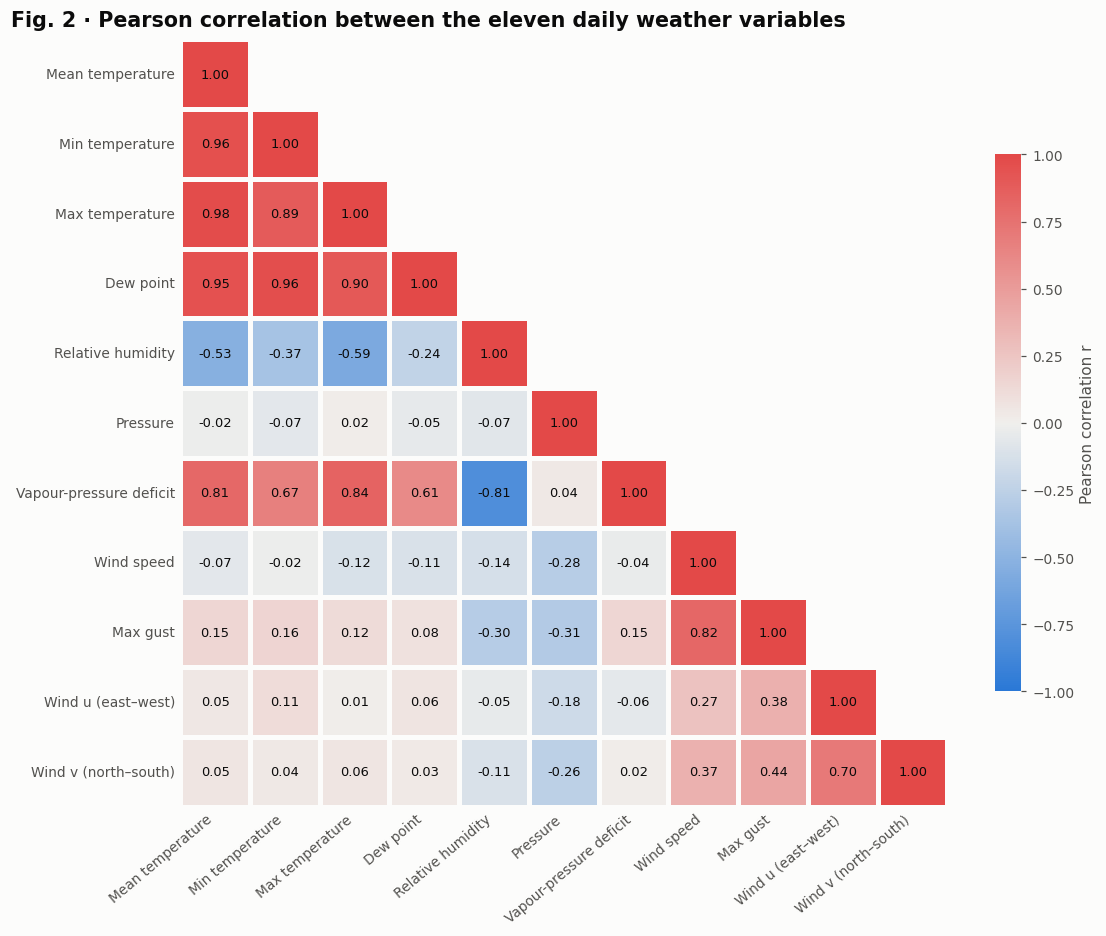

,mean,std,min,max
Mean temperature,9.44,7.83,-16.46,29.38
Min temperature,5.20,7.01,-23.01,20.64
Max temperature,13.75,8.99,-15.23,37.28
Dew point,4.96,6.58,-19.39,20.19
Relative humidity,76.04,11.37,37.58,100.00
Pressure,989.22,8.09,949.00,1013.96
Vapour-pressure deficit,4.03,3.55,0.00,24.01
Wind speed,2.13,0.97,0.00,7.64
Max gust,7.97,2.94,0.00,23.50
Wind u (east–west),0.41,1.14,-4.86,3.72


In [8]:
# ── 4.2  Fig. 2 — correlation structure ──────────────────────────────────────
corr = daily[WEATHER_VARS].corr()
names = [LABELS[c] for c in WEATHER_VARS]
fig, ax = plt.subplots(figsize=(10, 8.4))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap=DIVERGING, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8.5, "color": INK}, square=True, linewidths=2,
            linecolor=SURFACE, cbar_kws={"shrink": 0.7, "label": "Pearson correlation r"},
            xticklabels=names, yticklabels=names, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
finish(fig, 2, "Pearson correlation between the eleven daily weather variables", "correlation_heatmap")

summary = daily[WEATHER_VARS].describe().T[["mean", "std", "min", "max"]]
summary.index = [LABELS[c] for c in summary.index]
show_table(summary.round(2), 2, "Descriptive statistics of the daily series (2009–2016)", fmt="{:.2f}")

**Reading Fig. 2.** The temperature family (mean, minimum, maximum and dew point) is almost collinear (r ≈ 0.89–0.98), so a linear model gains little from adding them all. Pressure is almost uncorrelated with temperature at the daily scale. Its *changes*, though, signal approaching weather systems, a non-linear and time-lagged relationship that a recurrent network can learn but a correlation coefficient cannot show. Humidity is moderately anti-correlated with temperature, and the wind components carry largely independent information.

## 5 · Time-series diagnostics

**5.1 Decomposition.** STL (*Seasonal–Trend decomposition using LOESS*, Cleveland et al., 1990) splits the series into trend, seasonal and remainder components. It is applied to **weekly** mean temperature, with a period of 52 weeks. With daily data and only eight annual cycles, each calendar day's seasonal value would be estimated from just eight noisy observations, so the seasonal component would absorb individual weather events. Weekly averaging removes that day-to-day noise first, which is a typical use of resampling. The strength of each component is quantified as $F = \max\!\left(0,\, 1 - \tfrac{\operatorname{Var}(R)}{\operatorname{Var}(X + R)}\right)$ (Wang, Smith & Hyndman, 2006), where $X$ is the trend or the seasonal component and $R$ the remainder.

> STL is *two-sided*: each point is smoothed using both past **and future** values. It is therefore used only to describe the data here and **never** as a model input, which would leak future information.

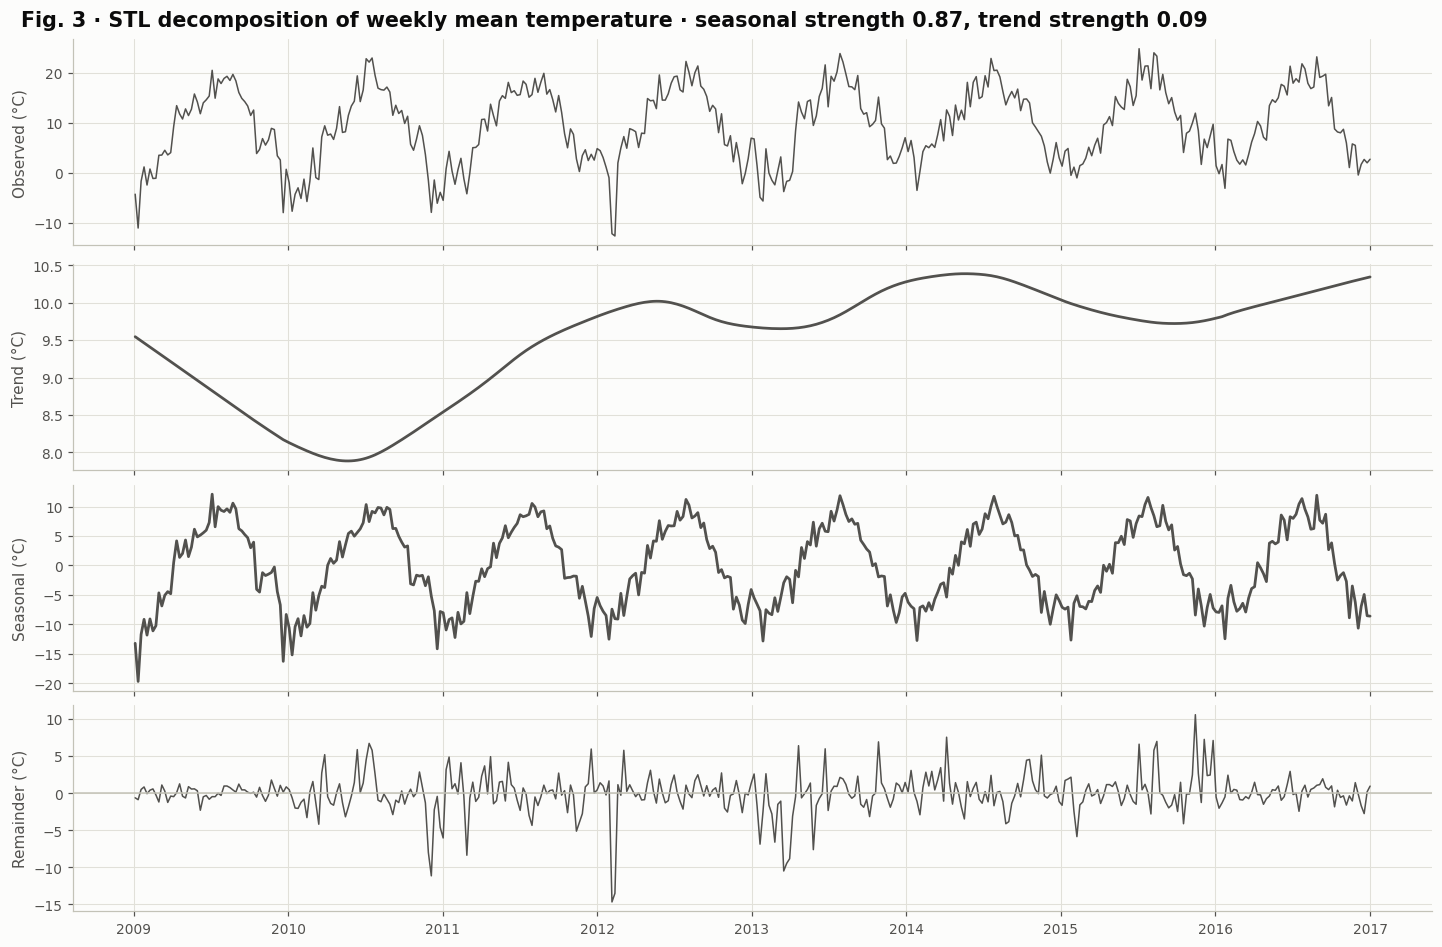

In [9]:
# ── 5.1  Fig. 3 — STL decomposition ─────────────────────────────────────────
weekly_T = daily["T"].resample("W").mean()
stl = STL(weekly_T, period=52, robust=True).fit()
def component_strength(component):
    return max(0.0, 1 - np.var(stl.resid) / np.var(component + stl.resid))
seasonal_strength, trend_strength = component_strength(stl.seasonal), component_strength(stl.trend)

parts = [(stl.observed, "Observed (°C)"), (stl.trend, "Trend (°C)"),
         (stl.seasonal, "Seasonal (°C)"), (stl.resid, "Remainder (°C)")]
fig, axes = plt.subplots(4, 1, figsize=(13, 8.5), sharex=True)
for ax, (series, label) in zip(axes, parts):
    ax.plot(series.index, series, color=INK_2, lw=1.0 if label.startswith(("Observed", "Remainder")) else 1.8)
    ax.set_ylabel(label)
axes[3].axhline(0, color=AXIS, lw=1)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
finish(fig, 3, f"STL decomposition of weekly mean temperature · seasonal strength {seasonal_strength:.2f}, "
               f"trend strength {trend_strength:.2f}", "stl_decomposition")

**5.2 Stationarity.** ARIMA-type models require a stationary series. Two complementary tests are run *on the training years only*:

* **ADF** (Augmented Dickey–Fuller), with H₀: *the series has a unit root*. A small p-value means the series is stationary.
* **KPSS** (Kwiatkowski–Phillips–Schmidt–Shin), with the opposite H₀: *the series is stationary*. A small p-value means it is non-stationary. It is run around a constant (level) and around a linear trend.

Agreement between the two tests is much stronger evidence than either test alone. The *deseasonalised anomaly* is the temperature minus its smooth annual cycle, estimated by least squares with three Fourier harmonics (§ 8).

In [10]:
# ── Shared helper: Fourier calendar terms (used by climatology, SARIMA and LSTM) ──
EPOCH = daily.index[0]

def fourier_terms(index, K, const=True):
    """Deterministic annual seasonality: K sine/cosine pairs with period 365.25 days (+ an intercept)."""
    t = (index - EPOCH).days.to_numpy(dtype=float)
    cols = {"const": np.ones(len(index))} if const else {}
    for k in range(1, K + 1):
        cols[f"sin{k}"] = np.sin(2 * np.pi * k * t / 365.25)
        cols[f"cos{k}"] = np.cos(2 * np.pi * k * t / 365.25)
    return pd.DataFrame(cols, index=index)

# ── 5.2  Table 3 — ADF and KPSS tests on the training period ─────────────────
train_T = daily["T"].loc[:TRAIN_END]
anomaly = train_T - sm.OLS(train_T, fourier_terms(train_T.index, 3)).fit().fittedvalues

def stationarity(series):
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_c, kpss_c_p, *_ = kpss(series, regression="c", nlags="auto")
    kpss_t, kpss_t_p, *_ = kpss(series, regression="ct", nlags="auto")
    if adf_p < 0.05 and kpss_c_p > 0.05:
        verdict = "Stationary"
    elif adf_p < 0.05 and kpss_t_p > 0.05:
        verdict = "Trend-stationary (no unit root)"
    elif adf_p >= 0.05 and min(kpss_c_p, kpss_t_p) <= 0.05:
        verdict = "Unit root → difference"
    else:
        verdict = "Inconclusive"
    return {"ADF statistic": adf_stat, "ADF p": adf_p, "KPSS level": kpss_c, "KPSS level p": kpss_c_p,
            "KPSS trend": kpss_t, "KPSS trend p": kpss_t_p, "Verdict": verdict}

stationarity_table = pd.DataFrame({
    "Daily temperature (raw)": stationarity(train_T),
    "First difference ΔT": stationarity(train_T.diff().dropna()),
    "Deseasonalised anomaly": stationarity(anomaly),
}).T
show_table(stationarity_table, 3, "Stationarity tests on the training years (2009–2014)",
           fmt={c: "{:.3f}" for c in stationarity_table.columns if c != "Verdict"})
print("KPSS p-values are interpolated from a look-up table and are capped to the interval [0.01, 0.10].")

,ADF statistic,ADF p,KPSS level,KPSS level p,KPSS trend,KPSS trend p,Verdict
Daily temperature (raw),-3.370,0.012,0.188,0.100,0.056,0.100,Stationary
First difference ΔT,-15.854,0.000,0.073,0.100,0.034,0.100,Stationary
Deseasonalised anomaly,-12.340,0.000,0.971,0.010,0.060,0.100,Trend-stationary (no unit root)


KPSS p-values are interpolated from a look-up table and are capped to the interval [0.01, 0.10].


**Interpretation.** Both tests classify the raw series as stationary: ADF rejects a unit root, and KPSS does not reject stationarity. The annual cycle is therefore a *deterministic* oscillation, not a stochastic trend. This has two modelling consequences:

1. **No differencing is required (d = 0).** Differencing a stationary series would add noise for nothing.
2. **Seasonality should be modelled explicitly**, with Fourier terms in SARIMA, rather than removed by seasonal differencing.

The deseasonalised anomaly has no unit root. The level-KPSS test reacts to a slow drift: the cold winters of 2009–2010 at the start of the training window are followed by milder years. The trend-KPSS test does not reject. Short-memory ARMA dynamics capture this behaviour without differencing.

**5.3 Autocorrelation.** The ACF measures how strongly the series correlates with its own past at each lag. The PACF measures the same thing after removing the influence of the intermediate lags. Together they reveal seasonality and suggest the orders of an ARMA model: a PACF that cuts off after *p* lags points to an AR(*p*) process.

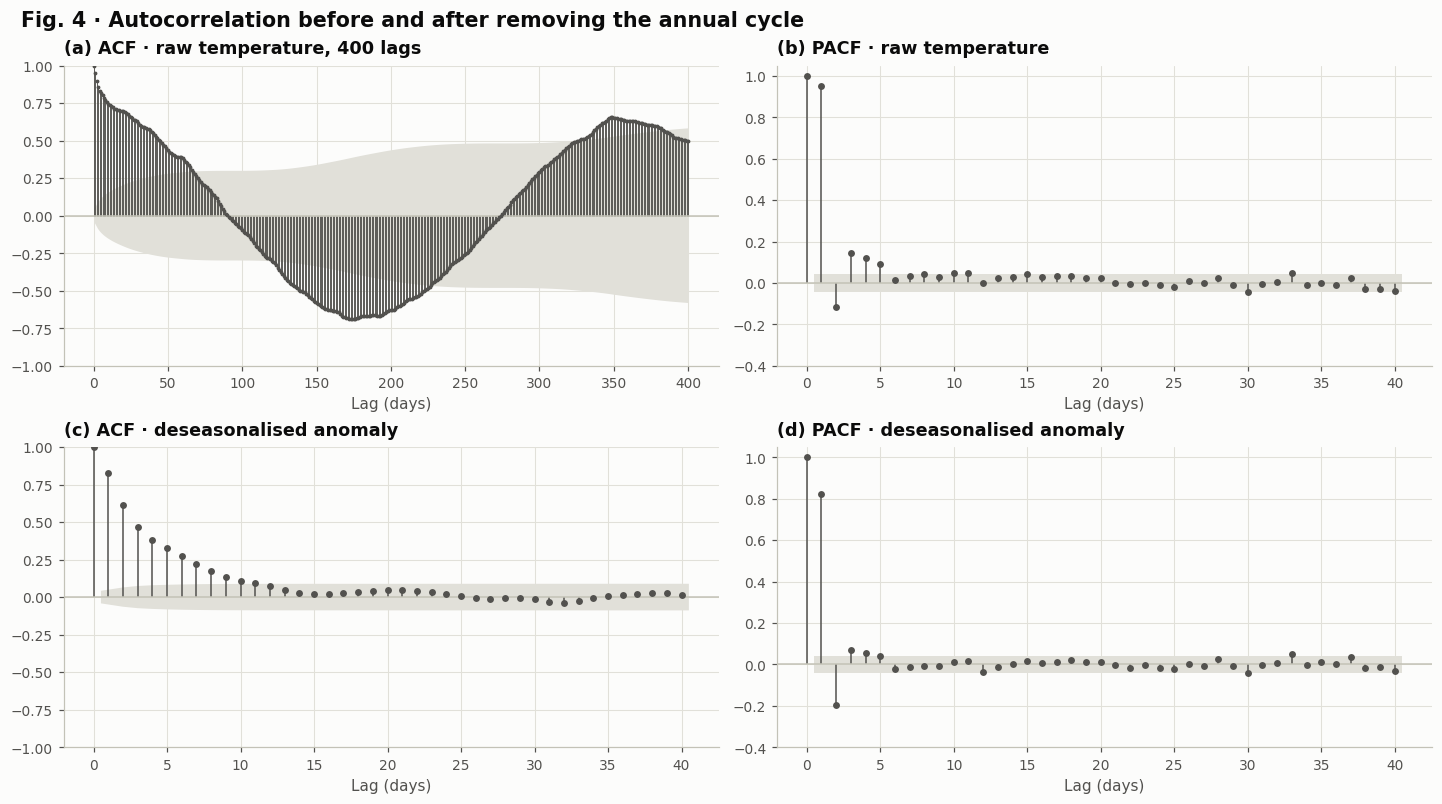

Significant PACF lags of the anomaly within the first 10: [1, 2, 3, 4, 5]


In [11]:
# ── 5.3  Fig. 4 — autocorrelation structure ────────────────────────────────
def tidy_correlogram(ax, title, color=INK_2, markersize=3.5):
    """Restyle a statsmodels correlogram: grey significance band behind the stems, themed markers."""
    for artist in ax.collections:
        if isinstance(artist, PolyCollection):           # the 95 % significance band
            artist.set_facecolor(GRID); artist.set_alpha(1.0); artist.set_zorder(0.5)
    for line in ax.lines:
        if line.get_marker() not in (None, "None", ""):  # correlation markers
            line.set_color(color); line.set_markersize(markersize)
        else:                                            # zero line
            line.set_color(AXIS); line.set_linewidth(1)
    ax.set_title(title); ax.set_xlabel("Lag (days)")

fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))
plot_acf(train_T, lags=400, ax=axes[0, 0], vlines_kwargs={"colors": INK_2, "lw": 0.6})
tidy_correlogram(axes[0, 0], "(a) ACF · raw temperature, 400 lags", markersize=1.5)
plot_pacf(train_T, lags=40, ax=axes[0, 1], method="ywm", vlines_kwargs={"colors": INK_2, "lw": 1})
tidy_correlogram(axes[0, 1], "(b) PACF · raw temperature")
plot_acf(anomaly, lags=40, ax=axes[1, 0], vlines_kwargs={"colors": INK_2, "lw": 1})
tidy_correlogram(axes[1, 0], "(c) ACF · deseasonalised anomaly")
plot_pacf(anomaly, lags=40, ax=axes[1, 1], method="ywm", vlines_kwargs={"colors": INK_2, "lw": 1})
tidy_correlogram(axes[1, 1], "(d) PACF · deseasonalised anomaly")
for ax in axes[:, 1]:
    ax.set_ylim(-0.4, 1.05)
finish(fig, 4, "Autocorrelation before and after removing the annual cycle", "acf_pacf")

significant = np.abs(sm.tsa.pacf(anomaly, nlags=10, method="ywm")[1:]) > 1.96 / np.sqrt(len(anomaly))
print(f"Significant PACF lags of the anomaly within the first 10: {[int(lag) for lag in np.flatnonzero(significant) + 1]}")

**Reading Fig. 4.** (a) The raw ACF oscillates with a 365-day period, the signature of annual seasonality: temperatures are positively correlated with the same season and negatively correlated with the opposite one. (c–d) After the annual cycle is removed, the ACF decays geometrically and the PACF drops to near zero after a few lags. This is a short-memory **autoregressive** structure, so tomorrow's anomaly depends mainly on the last few days. It suggests a low-order ARMA model for the anomaly; the exact orders are chosen by AIC below.

## 6 · Experimental design

**Rolling-origin protocol.** Every day of the evaluation period is a forecast *target* at every lead time $h = 1, \dots, H$. The forecast of day $j$ at lead $h$ is issued at the *origin* $j - h$, using only information available on that day. Some origins therefore lie before the test year: a 90-day-ahead forecast of 1 January 2016 is issued on 3 October 2015. Model **parameters are estimated once on the training years and then frozen**. As new days arrive, models only update their *state*: the Kalman filter for ARIMA and SARIMA, the sliding input window for the LSTM. This mirrors operational forecasting. Because **every lead time is scored on exactly the same 366 test days**, differences between lead times reflect the lead alone, not the season of the days that happen to be scored.

**Safeguards against data leakage**
* The split is chronological: no shuffling across time, and the test year is used exactly once.
* The feature scaler, the climatology and every model parameter are estimated from **training data only**.
* The validation year (2015) is used only for early stopping, hybrid weights and interval calibration.
* STL (two-sided) is used only for description and never as a model input.

**Metrics** (computed on errors $e_t = y_t - \hat y_t$ over the test year)

| Metric | Definition | Why |
|---|---|---|
| RMSE | $\sqrt{\tfrac1n\sum e_t^2}$ | penalises large misses; same unit as the data (°C) |
| MAE | $\tfrac1n\sum \lvert e_t\rvert$ | typical error size, robust to outliers |
| MAPE | $\tfrac{100}{n}\sum \lvert e_t\rvert / (y_t + 273.15)$ | relative error, computed in **kelvin** (see note) |
| R² | $1 - \sum e_t^2 / \sum (y_t - \bar y)^2$ | share of variance explained |
| MASE | $\text{MAE} / \tfrac{1}{n_{tr}-1}\sum \lvert y_t - y_{t-1}\rvert_{\text{train}}$ | scale-free; below 1 beats the naïve forecast (Hyndman & Koehler, 2006) |
| Skill | $1 - \text{MSE} / \text{MSE}_{\text{persistence}}$ | meteorological skill score; above 0 beats persistence |

> **Why MAPE is computed in kelvin.** The Celsius scale has an arbitrary zero. In winter the daily mean crosses 0 °C, so a 1 °C error on a 0.1 °C day would count as a "1000 % error" and Celsius MAPE explodes. Percentage errors are only meaningful on a ratio scale with a true zero, which for temperature is the kelvin scale. MAPE values are therefore small, and **RMSE, MAE and the skill scores remain the primary basis for comparison**.

**Baselines.** Any useful model has to beat two naïve forecasts:
* **Persistence:** $\hat y_{t+h} = y_t$, "the weather stays as it is today". This is very hard to beat one day ahead.
* **Climatology:** $\hat y_{t+h}$ is the long-run average temperature for that calendar day, a three-harmonic annual cycle fitted on the training years.

In [12]:
# ── 6.1  Split, forecast targets and forecast origins ───────────────────────
y = daily["T"]
yv = y.to_numpy()
n = len(y)
n_train = int((y.index <= TRAIN_END).sum())
n_val = int(((y.index > TRAIN_END) & (y.index <= VAL_END)).sum())

# Every validation/test day is a forecast TARGET at every lead h = 1…H. The forecast of target day j at lead h
# is issued at ORIGIN j − h (the end of that day) from data up to that day only.
VAL_TARGETS = np.arange(n_train, n_train + n_val)
TEST_TARGETS = np.arange(n_train + n_val, n)
LEADS = np.arange(1, H + 1)
ORIGINS = np.arange(n_train - H, n - 1)                      # every origin needed to reach those targets
VAL_ORIGINS = VAL_TARGETS - 1                                # day-ahead origins of the validation year
Y_VAL, Y_TEST = yv[VAL_TARGETS], yv[TEST_TARGETS]
future_index = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=H, freq="D")
calendar_index = y.index.append(future_index)                # observed days + the H future days

def by_target(paths, targets):
    """Re-index forecasts from origin rows (ORIGINS × leads) to target rows (target days × leads)."""
    rows = targets[:, None] - LEADS[None, :] - ORIGINS[0]
    return paths[rows, LEADS - 1]

FC = {}   # FC[model] = {"val": 365 × H, "test": 366 × H (row = target day, column = lead), "future": H}

def register(name, origin_paths, future_path):
    """Store a model's forecasts of every validation/test day at every lead, plus its future path."""
    FC[name] = {"val": by_target(origin_paths, VAL_TARGETS), "test": by_target(origin_paths, TEST_TARGETS),
                "future": np.asarray(future_path, dtype=float)}

split_table = pd.DataFrame({
    "Period": [f"{y.index[0]:%d %b %Y} → {y.index[n_train - 1]:%d %b %Y}",
               f"{y.index[n_train]:%d %b %Y} → {y.index[n_train + n_val - 1]:%d %b %Y}",
               f"{y.index[n_train + n_val]:%d %b %Y} → {y.index[-1]:%d %b %Y}"],
    "Days": [n_train, n_val, n - n_train - n_val],
    "Used for": ["estimating every model parameter", "early stopping · hybrid weights · interval calibration",
                 "final, one-time evaluation: every day is a target at every lead time"]},
    index=["Training", "Validation", "Test"])
show_table(split_table, 4, "Chronological data split", fmt={"Days": "{:,}"})

# ── 6.2  Metrics ─────────────────────────────────────────────────────────────
MASE_SCALE = np.mean(np.abs(np.diff(yv[:n_train])))         # in-sample MAE of the naïve forecast

def metrics(y_true, y_pred):
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    t, p = y_true[ok], y_pred[ok]
    e = t - p
    return {"RMSE (°C)": np.sqrt(np.mean(e ** 2)), "MAE (°C)": np.mean(np.abs(e)),
            "MAPE (%)": 100 * np.mean(np.abs(e) / (t + 273.15)), "R²": r2_score(t, p),
            "MASE": np.mean(np.abs(e)) / MASE_SCALE}

def rmse_by_horizon(F, Y):
    return np.sqrt(np.mean((Y[:, None] - F) ** 2, axis=0))

# ── 6.3  Baselines ───────────────────────────────────────────────────────────
climatology_fit = sm.OLS(y.iloc[:n_train], fourier_terms(y.index[:n_train], 3)).fit()
climatology = (fourier_terms(calendar_index, 3) @ climatology_fit.params).to_numpy()

register("Persistence", np.repeat(yv[ORIGINS][:, None], H, axis=1), np.full(H, yv[-1]))
register("Climatology", climatology[ORIGINS[:, None] + LEADS], climatology[n:n + H])
for name in ("Persistence", "Climatology"):
    print(f"{name:<12} day-ahead test RMSE: {metrics(Y_TEST, FC[name]['test'][:, 0])['RMSE (°C)']:.3f} °C")

,Period,Days,Used for
Training,01 Jan 2009 → 31 Dec 2014,"2,191",estimating every model parameter
Validation,01 Jan 2015 → 31 Dec 2015,365,early stopping · hybrid weights · interval calibration
Test,01 Jan 2016 → 31 Dec 2016,366,"final, one-time evaluation: every day is a target at every lead time"


Persistence  day-ahead test RMSE: 2.340 °C
Climatology  day-ahead test RMSE: 3.764 °C


## 7 · ARIMA

An ARIMA$(p,d,q)$ model (Box & Jenkins, 1970) describes the series by its own past values and past shocks:

$$\phi(B)\,(1-B)^d\,(y_t - \mu) = \theta(B)\,\varepsilon_t,\qquad \varepsilon_t \sim \mathcal N(0,\sigma^2),$$

where $B$ is the back-shift operator, $\phi(B) = 1-\phi_1B-\dots-\phi_pB^p$ and $\theta(B) = 1+\theta_1B+\dots+\theta_qB^q$. The integration order $d$ comes from Table 3. The orders $p, q \in \{0,\dots,3\}$ are chosen by the **Akaike Information Criterion** $\text{AIC} = 2k - 2\ln\hat L$, which rewards goodness of fit but penalises every extra parameter. ARIMA has **no seasonal component**, so it is the reference that shows how much modelling seasonality is worth.

**Exact forecasts from every origin, in one pass.** A classical implementation would re-run the model once for each of the 731 validation and test origins. Here the model is written in state-space form and the Kalman filter runs over the full series **once**, with parameters frozen. The filter's one-step-ahead state at each origin is then propagated $h$ steps forward with the transition matrix. The result is identical to statsmodels' own `get_forecast()` (verified below) and about a thousand times faster.

In [13]:
# ── 7.1  Shared helpers for state-space models ──────────────────────────────
def aic_search(endog, exog, orders):
    """Fit every (p, d, q) candidate by maximum likelihood and rank the candidates by AIC."""
    rows = []
    for p, d, q in orders:
        res = SARIMAX(endog, exog=exog, order=(p, d, q), trend="n").fit(disp=False)
        rows.append({"p": p, "d": d, "q": q, "AIC": res.aic, "BIC": res.bic,
                     "converged": bool(res.mle_retvals.get("converged", True)), "result": res})
    table = pd.DataFrame(rows)
    table = table.sort_values(["converged", "AIC"], ascending=[False, True]).reset_index(drop=True)
    table.insert(5, "ΔAIC", table["AIC"] - table["AIC"].iloc[0])      # row 0 = best converged model
    return table

def state_space_paths(res, endog, exog=None, exog_future=None):
    """Exact h-step forecasts ŷ(i+h | i) from EVERY origin i in a single Kalman-filter pass.

    The fitted model (parameters frozen) is re-filtered over the full series. The one-step predicted
    state a(i+1|i) is then propagated with the transition matrix T:  a(i+h|i) = T^(h-1)·a(i+1|i),
    and ŷ(i+h|i) = x(i+h)'β + Z·a(i+h|i).  Returns an (n × H) matrix and the filtered results.
    """
    full = res.apply(endog, exog=exog)
    fr = full.filter_results
    Z, T, c = fr.design[:, :, 0], fr.transition[:, :, 0], fr.state_intercept[:, 0]
    m = len(endog)
    A = fr.predicted_state[:, 1:m + 1].copy()                 # a(i+1|i) for every origin i
    xb = np.zeros(m + H)
    if exog is not None:
        beta = res.params[list(exog.columns)].to_numpy()
        xb = np.vstack([exog.to_numpy(), exog_future.to_numpy()]) @ beta
    paths = np.empty((m, H))
    for h in range(H):
        paths[:, h] = xb[np.arange(m) + h + 1] + (Z @ A)[0]
        A = T @ A + c[:, None]
    return paths, full

def verify_paths(res, paths, endog, exog=None, exog_future=None, origin=None):
    """Check one origin against statsmodels' native multi-step forecasting routine."""
    origin = TEST_TARGETS[len(TEST_TARGETS) // 2] if origin is None else origin
    exog_all = None if exog is None else pd.concat([exog, exog_future])
    partial = res.apply(endog.iloc[:origin + 1], exog=None if exog is None else exog.iloc[:origin + 1])
    reference = partial.get_forecast(H, exog=None if exog is None else exog_all.iloc[origin + 1:origin + 1 + H])
    gap = np.max(np.abs(reference.predicted_mean.to_numpy() - paths[origin]))
    assert gap < 1e-6, f"state-space paths disagree with statsmodels (max gap {gap:.2e})"
    print(f"✓ Vectorised forecasts match statsmodels get_forecast() exactly (max |difference| = {gap:.1e} °C)")

def parameter_table(res):
    return pd.DataFrame({"estimate": res.params, "std. error": res.bse, "z": res.tvalues, "p-value": res.pvalues})

In [14]:
# ── 7.2  Order selection and estimation ─────────────────────────────────────
D_ORDER = 0 if stationarity_table.loc["Daily temperature (raw)", "ADF p"] < 0.05 else 1
mean_term = pd.DataFrame({"mean": np.ones(len(calendar_index))}, index=calendar_index)
arima_exog = mean_term.iloc[:n] if D_ORDER == 0 else None          # a constant mean is only identifiable if d = 0
arima_exog_future = mean_term.iloc[n:] if D_ORDER == 0 else None

t0 = time.time()
arima_search = aic_search(y.iloc[:n_train], None if arima_exog is None else arima_exog.iloc[:n_train],
                          [(p, D_ORDER, q) for p in range(4) for q in range(4)])
arima_res = arima_search.loc[0, "result"]
ARIMA_ORDER = tuple(int(v) for v in arima_search.loc[0, ["p", "d", "q"]])
print(f"Searched {len(arima_search)} candidate models in {time.time() - t0:.1f} s → ARIMA{ARIMA_ORDER} selected")
show_table(arima_search.drop(columns="result").head(5), 5, "ARIMA candidates ranked by AIC (top 5)",
           fmt={"AIC": "{:.1f}", "ΔAIC": "{:.1f}", "BIC": "{:.1f}"}, index=False)
show_table(parameter_table(arima_res), 6, f"ARIMA{ARIMA_ORDER} parameter estimates (training years)")

Searched 16 candidate models in 11.4 s → ARIMA(3, 0, 1) selected


p,d,q,AIC,BIC,ΔAIC,converged
3,0,1,9882.6,9916.7,0.0,True
2,0,3,9883.2,9923.1,0.7,True
3,0,2,9883.4,9923.2,0.8,True
2,0,2,9885.0,9919.1,2.4,True
1,0,3,9916.2,9950.3,33.6,True


,estimate,std. error,z,p-value
mean,8.199,2.119,3.870,0.000
ar.L1,1.882,0.032,58.998,0.000
ar.L2,-1.117,0.041,-27.285,0.000
ar.L3,0.232,0.020,11.598,0.000
ma.L1,-0.843,0.026,-32.148,0.000
sigma2,5.290,0.141,37.525,0.000


In [15]:
# ── 7.3  Forecasts from every validation / test origin ──────────────────────
F_arima, arima_full = state_space_paths(arima_res, y, arima_exog, arima_exog_future)
verify_paths(arima_res, F_arima, y, arima_exog, arima_exog_future)
register("ARIMA", F_arima[ORIGINS], F_arima[n - 1])
print(f"ARIMA day-ahead test RMSE: {metrics(Y_TEST, FC['ARIMA']['test'][:, 0])['RMSE (°C)']:.3f} °C")

✓ Vectorised forecasts match statsmodels get_forecast() exactly (max |difference| = 0.0e+00 °C)
ARIMA day-ahead test RMSE: 2.226 °C


## 8 · SARIMA with Fourier seasonality

The textbook multiplicative SARIMA$(p,d,q)(P,D,Q)_s$ is designed for short seasonal periods such as $s = 12$ for monthly data. Daily temperature has an annual period of $s = 365.25$ days, which breaks it in three ways:

* **It is computationally intractable.** A SARIMA$(1,0,1)(1,1,1)_{365}$ has a 732-dimensional state vector. The Kalman filter would have to store a 732 × 732 covariance matrix at every one of the ~2 200 training days, more than 9 GB of RAM, for every likelihood evaluation.
* **Seasonal differencing at lag 365 doubles the noise.** $y_t - y_{t-365}$ subtracts last year's *weather* along with the climate, so the variance of the noise roughly doubles.
* **The period is not an integer.** Leap years make a fixed lag of 365 drift out of phase.

The standard remedy (Hyndman & Athanasopoulos, 2021, §10.5) keeps the seasonal ARIMA structure but represents the seasonal component with **Fourier terms**:

$$y_t = \mu + \sum_{k=1}^{K}\Big[a_k \sin\tfrac{2\pi k t}{365.25} + b_k \cos\tfrac{2\pi k t}{365.25}\Big] + u_t, \qquad \phi(B)\,u_t = \theta(B)\,\varepsilon_t .$$

The seasonal part is smooth, exactly periodic and costs only $2K$ parameters, and the ARMA errors $u_t$ capture day-to-day persistence. All coefficients are estimated **jointly** by maximum likelihood. Model selection has two stages: first the number of harmonics $K$, using AR(1) errors; then the ARMA orders $(p, q)$, both by AIC.

In [16]:
# ── 8.1  Stage 1 — number of Fourier harmonics K ────────────────────────────
t0 = time.time()
harmonics = []
for K in range(1, 5):
    res = SARIMAX(y.iloc[:n_train], exog=fourier_terms(y.index[:n_train], K), order=(1, 0, 0), trend="n").fit(disp=False)
    harmonics.append({"Fourier pairs K": K, "seasonal parameters": 2 * K, "AIC": res.aic, "BIC": res.bic})
harmonics = pd.DataFrame(harmonics)
K_BEST = int(harmonics.loc[harmonics["AIC"].idxmin(), "Fourier pairs K"])

# ── 8.2  Stage 2 — ARMA orders of the error process ─────────────────────────
sarima_exog = fourier_terms(calendar_index, K_BEST)
sarima_search = aic_search(y.iloc[:n_train], sarima_exog.iloc[:n_train], [(p, 0, q) for p in range(4) for q in range(4)])
sarima_res = sarima_search.loc[0, "result"]
SARIMA_ORDER = tuple(int(v) for v in sarima_search.loc[0, ["p", "d", "q"]])
print(f"{len(harmonics) + len(sarima_search)} models fitted in {time.time() - t0:.1f} s → "
      f"SARIMAX{SARIMA_ORDER} + {K_BEST} Fourier pair(s) selected")
show_table(harmonics, 7, "Stage 1 — choosing the number of Fourier harmonics (AR(1) errors)",
           fmt={"AIC": "{:.1f}", "BIC": "{:.1f}"}, low=["AIC"], index=False)
show_table(sarima_search.drop(columns="result").head(5), 8, "Stage 2 — ARMA error orders ranked by AIC (top 5)",
           fmt={"AIC": "{:.1f}", "ΔAIC": "{:.1f}", "BIC": "{:.1f}"}, index=False)
show_table(parameter_table(sarima_res), 9, "SARIMA parameter estimates (training years)")

# Interpret the fitted annual cycle
one_year = pd.date_range("2015-01-01", "2015-12-31", freq="D")
seasonal_curve = fourier_terms(one_year, K_BEST) @ sarima_res.params[sarima_exog.columns]
print(f"Fitted annual cycle: amplitude ±{(seasonal_curve.max() - seasonal_curve.min()) / 2:.1f} °C · "
      f"warmest around {seasonal_curve.idxmax():%d %b} · coldest around {seasonal_curve.idxmin():%d %b}")

20 models fitted in 11.7 s → SARIMAX(3, 0, 1) + 1 Fourier pair(s) selected


Fourier pairs K,seasonal parameters,AIC,BIC
1,2,9883.7,9912.2
2,4,9886.7,9926.5
3,6,9887.8,9939.0
4,8,9891.0,9953.6


p,d,q,AIC,BIC,ΔAIC,converged
3,0,1,9784.2,9829.8,0.0,True
3,0,2,9784.3,9835.5,0.0,True
3,0,3,9784.5,9841.4,0.3,True
2,0,3,9788.5,9839.8,4.3,True
3,0,0,9790.3,9830.1,6.0,True


,estimate,std. error,z,p-value
const,9.161,0.281,32.558,0.000
sin1,-2.539,0.413,-6.142,0.000
cos1,-9.335,0.385,-24.266,0.000
ar.L1,1.533,0.154,9.922,0.000
ar.L2,-0.798,0.147,-5.409,0.000
ar.L3,0.184,0.029,6.450,0.000
ma.L1,-0.532,0.157,-3.401,0.001
sigma2,5.053,0.133,37.856,0.000


Fitted annual cycle: amplitude ±9.7 °C · warmest around 19 Jul · coldest around 17 Jan


**Impulse response (ψ-weights).** Any stationary ARMA model can be rewritten as $u_t = \sum_{j\ge0}\psi_j\,\varepsilon_{t-j}$, where $\psi_j$ measures how much of today's surprise is still felt $j$ days later. These weights describe SARIMA's "memory" of weather anomalies, and the residual hybrid in § 10 uses them to carry its correction forward in time.

In [17]:
# ── 8.3  Forecasts from every origin + impulse response ─────────────────────
F_sarima, sarima_full = state_space_paths(sarima_res, y, sarima_exog.iloc[:n], sarima_exog.iloc[n:])
verify_paths(sarima_res, F_sarima, y, sarima_exog.iloc[:n], sarima_exog.iloc[n:])
register("SARIMA", F_sarima[ORIGINS], F_sarima[n - 1])

PSI = arma2ma(np.r_[1, -sarima_res.arparams], np.r_[1, sarima_res.maparams], lags=H)
print(f"SARIMA day-ahead test RMSE: {metrics(Y_TEST, FC['SARIMA']['test'][:, 0])['RMSE (°C)']:.3f} °C")
print("ψ-weights (share of a shock still present after j days): " +
      ", ".join(f"j={j}: {PSI[j]:.2f}" for j in (0, 1, 2, 3, 5, 7, 14)))

✓ Vectorised forecasts match statsmodels get_forecast() exactly (max |difference| = 0.0e+00 °C)
SARIMA day-ahead test RMSE: 2.164 °C
ψ-weights (share of a shock still present after j days): j=0: 1.00, j=1: 1.00, j=2: 0.74, j=3: 0.51, j=5: 0.32, j=7: 0.23, j=14: 0.08


## 9 · LSTM — a multi-task recurrent network

**Why an LSTM.** A Long Short-Term Memory network (Hochreiter & Schmidhuber, 1997) reads a sequence one day at a time. It carries a *cell state* $c_t$ that is updated through three learned gates:

$$f_t=\sigma(W_f[h_{t-1},x_t]+b_f),\quad i_t=\sigma(W_i[h_{t-1},x_t]+b_i),\quad o_t=\sigma(W_o[h_{t-1},x_t]+b_o)$$
$$c_t = f_t\odot c_{t-1} + i_t\odot\tanh(W_c[h_{t-1},x_t]+b_c),\qquad h_t = o_t\odot\tanh(c_t).$$

Because the cell state is updated additively, gradients survive across many time steps. This lets the network learn non-linear, multivariate and time-lagged relations, for example *falling pressure followed by a wind shift → a front → a temperature change*, which a linear ARIMA cannot represent.

**Design decisions**

| Choice | Rationale |
|---|---|
| **Inputs:** 30-day window × 13 features (11 weather variables + sin/cos of the annual phase) | the calendar features let the network place any day in the seasonal cycle, and they are known exactly for future dates |
| **Multi-task output:** tomorrow's *change* $\Delta x_{t+1}$ in **all 11** variables | predicting the whole weather state forces the network to learn joint atmospheric dynamics, a richer training signal than temperature alone; it also makes recursive multi-step forecasting possible |
| **Change (Δ) targets**, each scaled to unit variance | "no change" (persistence) becomes the network's default, the targets are stationary, and every task carries equal weight |
| **Recursive multi-step:** each predicted day is appended to the window and the network is applied again | gives forecasts at any horizon; the cost is error accumulation, which § 11 measures explicitly |
| **Seed ensemble** of $N$ networks, averaged | averaging independently initialised networks reduces variance and makes results reproducible (Lakshminarayanan et al., 2017) |
| **Regularisation:** dropout 0.2, early stopping on the validation year, learning-rate decay | a guard against over-fitting with about 2 000 training windows |

```
 input window  (30 days × 13 features)
      └─ LSTM · 64 units, returns the full sequence ─ Dropout 0.2
          └─ LSTM · 32 units, returns the last state ─ Dropout 0.2
              └─ Dense · 32 units, ReLU
                  └─ Dense · 11 units, linear  →  Δx(t+1): tomorrow's change in every weather variable
```

In [18]:
# ── 9.1  Features, scaling (fitted on training days only) and targets ───────
CAL = fourier_terms(calendar_index, 1, const=False)            # sin1, cos1 of the annual phase — known for any date
FEATURES = WEATHER_VARS + list(CAL.columns)
N_W = len(WEATHER_VARS)
frame = pd.concat([daily, CAL.iloc[:n]], axis=1)[FEATURES]

scaler = StandardScaler().fit(frame.iloc[:n_train])
X_all = scaler.transform(frame).astype("float32")              # (n days × 13 features)
CAL_SCALED = ((CAL.to_numpy() - scaler.mean_[N_W:]) / scaler.scale_[N_W:]).astype("float32")  # incl. future days
T_MEAN, T_STD = scaler.mean_[0], scaler.scale_[0]

DELTA = np.diff(X_all[:, :N_W], axis=0)                        # DELTA[i] = x(i+1) − x(i)   (scaled units)
DELTA_STD = DELTA[:n_train - 1].std(axis=0)                    # per-task target scale, training days only
TRAIN_ORIGINS = np.arange(LOOKBACK - 1, n_train - 1)           # the last target is the last training day

def windows(X, origins):
    """Stack the LOOKBACK days ending at each origin → tensor of shape (origins, LOOKBACK, features)."""
    return np.stack([X[i - LOOKBACK + 1:i + 1] for i in origins]).astype("float32")

def lstm_targets(origins):
    return (DELTA[origins] / DELTA_STD).astype("float32")

print(f"Training windows {len(TRAIN_ORIGINS):,} · validation windows {len(VAL_ORIGINS):,} · "
      f"input shape ({LOOKBACK}, {len(FEATURES)}) · outputs {N_W}")

Training windows 2,161 · validation windows 365 · input shape (30, 13) · outputs 11


In [19]:
# ── 9.2  Architecture and ensemble training ─────────────────────────────────
def build_lstm(n_features, n_outputs, seed, name):
    keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(LOOKBACK, n_features), name="weather_window")
    x = keras.layers.LSTM(64, return_sequences=True, name="lstm_64")(inputs)
    x = keras.layers.Dropout(0.2, name="dropout_1")(x)
    x = keras.layers.LSTM(32, name="lstm_32")(x)
    x = keras.layers.Dropout(0.2, name="dropout_2")(x)
    x = keras.layers.Dense(32, activation="relu", name="dense_32")(x)
    outputs = keras.layers.Dense(n_outputs, name="next_day_changes")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

def train_ensemble(X, target_fn, name):
    """Train N_ENSEMBLE independently seeded networks with early stopping on the validation year."""
    X_tr, Y_tr = windows(X, TRAIN_ORIGINS), target_fn(TRAIN_ORIGINS)
    X_va, Y_va = windows(X, VAL_ORIGINS), target_fn(VAL_ORIGINS)
    members, histories = [], []
    for k in range(N_ENSEMBLE):
        t0 = time.time()
        model = build_lstm(X.shape[1], Y_tr.shape[1], SEED + k, f"{name}_{k + 1}")
        history = model.fit(X_tr, Y_tr, validation_data=(X_va, Y_va), epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                            verbose=0, callbacks=[
                                keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
                                keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5)])
        members.append(model)
        histories.append(history.history)
        best = int(np.argmin(history.history["val_loss"]))
        print(f"  {name} · member {k + 1}/{N_ENSEMBLE}: best epoch {best + 1:>3} of {len(history.history['loss'])}, "
              f"validation loss {history.history['val_loss'][best]:.4f}  ({time.time() - t0:.0f} s)")
    return members, histories

lstm_members, lstm_histories = train_ensemble(X_all, lstm_targets, "lstm")
lstm_members[0].summary()

  lstm · member 1/3: best epoch  15 of 30, validation loss 0.8635  (40 s)


  lstm · member 2/3: best epoch  21 of 36, validation loss 0.8440  (37 s)


  lstm · member 3/3: best epoch  25 of 40, validation loss 0.8300  (52 s)


Model: "lstm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ weather_window (InputLayer)     │ (None, 30, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_day_changes (Dense)        │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,411 (396.14 KB)

 Trainable params: 33,803 (132.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,608 (264.10 KB)

In [20]:
# ── 9.3  Recursive multi-step forecasting ───────────────────────────────────
def lstm_paths(members, origins):
    """Forecast H days ahead by feeding each predicted day back into the window (ensemble mean, °C)."""
    runs = []
    for model in members:
        window = windows(X_all, origins)
        path = np.empty((len(origins), H))
        for h in range(1, H + 1):
            change = model.predict_on_batch(window) * DELTA_STD           # predicted Δ of every weather variable
            weather = window[:, -1, :N_W] + change
            next_day = np.concatenate([weather, CAL_SCALED[origins + h]], axis=1).astype("float32")
            window = np.concatenate([window[:, 1:], next_day[:, None, :]], axis=1)
            path[:, h - 1] = weather[:, 0] * T_STD + T_MEAN
        runs.append(path)
    return np.mean(runs, axis=0)

t0 = time.time()
lstm_origin_paths = lstm_paths(lstm_members, np.append(ORIGINS, n - 1))      # last row: the real future
register("LSTM", lstm_origin_paths[:-1], lstm_origin_paths[-1])
print(f"Recursive {H}-day forecasts from {len(ORIGINS) + 1:,} origins in {time.time() - t0:.0f} s")
print(f"LSTM day-ahead test RMSE: {metrics(Y_TEST, FC['LSTM']['test'][:, 0])['RMSE (°C)']:.3f} °C")

Recursive 90-day forecasts from 821 origins in 12 s
LSTM day-ahead test RMSE: 2.017 °C


## 10 · Hybrid models

Zhang (2003) argued that a real series is the sum of a **linear** part $L_t$ and a **non-linear** part $N_t$, and that no single model class captures both. Two hybridisation strategies are compared.

### 10.1 Hybrid-R — SARIMA + LSTM residual learner

1. SARIMA explains the linear structure: the annual cycle and ARMA persistence. Its one-step forecast error $e_{t+1} = y_{t+1} - \hat y^{\,\text{SARIMA}}_{t+1\mid t}$ contains whatever the linear model missed.
2. An LSTM with the same architecture as § 9 learns to **predict that error**. Its inputs are the 30-day weather window plus SARIMA's recent errors. Its outputs are $\hat e_{t+1}$ (main task) and tomorrow's change in the other ten variables. SARIMA's errors are close to white noise, so a network trained on them alone has little signal to learn from and easily settles on predicting ≈ 0. The auxiliary tasks give it a dense, physically meaningful training signal.
3. **Day-ahead:** $\hat y^{\,\text{HR}}_{t+1} = \hat y^{\,\text{SARIMA}}_{t+1\mid t} + \hat e_{t+1}$.
4. **Multi-step:** the correction is treated as tomorrow's "news" and propagated through SARIMA's own impulse response:

$$\hat y^{\,\text{HR}}_{t+h\mid t} = \hat y^{\,\text{SARIMA}}_{t+h\mid t} + \psi_{h-1}\,\hat e_{t+1}.$$

This is the forecast SARIMA itself would issue if it were told tomorrow's value $\hat y^{\,\text{HR}}_{t+1}$. The correction fades exactly as fast as real weather anomalies do, so the hybrid never inherits the LSTM's recursive drift.

In [21]:
# ── 10.1  Hybrid-R: residual learner on SARIMA's one-step errors ────────────
innovations = sarima_full.resid.to_numpy()                       # e(t) = y(t) − ŷ(t | t−1), causal
INNOV_STD = innovations[1:n_train].std()
X_res = np.concatenate([X_all, (innovations / INNOV_STD)[:, None]], axis=1).astype("float32")   # 14 inputs

def residual_targets(origins):
    targets = DELTA[origins] / DELTA_STD                         # auxiliary tasks: Δ of every weather variable …
    targets[:, 0] = innovations[origins + 1] / INNOV_STD         # … with task 0 replaced by SARIMA's error tomorrow
    return targets.astype("float32")

residual_members, residual_histories = train_ensemble(X_res, residual_targets, "residual_lstm")

def predicted_correction(origins):
    window = windows(X_res, origins)
    return np.mean([m.predict_on_batch(window)[:, 0] for m in residual_members], axis=0) * INNOV_STD

def hybrid_r_paths(origins):
    return F_sarima[origins] + predicted_correction(origins)[:, None] * PSI[None, :]

hybrid_origin_paths = hybrid_r_paths(np.append(ORIGINS, n - 1))                # last row: the real future
register("Hybrid-R", hybrid_origin_paths[:-1], hybrid_origin_paths[-1])
print(f"Hybrid-R day-ahead test RMSE: {metrics(Y_TEST, FC['Hybrid-R']['test'][:, 0])['RMSE (°C)']:.3f} °C")

  residual_lstm · member 1/3: best epoch  23 of 38, validation loss 0.8715  (49 s)


  residual_lstm · member 2/3: best epoch  18 of 33, validation loss 0.8692  (43 s)


  residual_lstm · member 3/3: best epoch  17 of 32, validation loss 0.8744  (42 s)


Hybrid-R day-ahead test RMSE: 2.033 °C


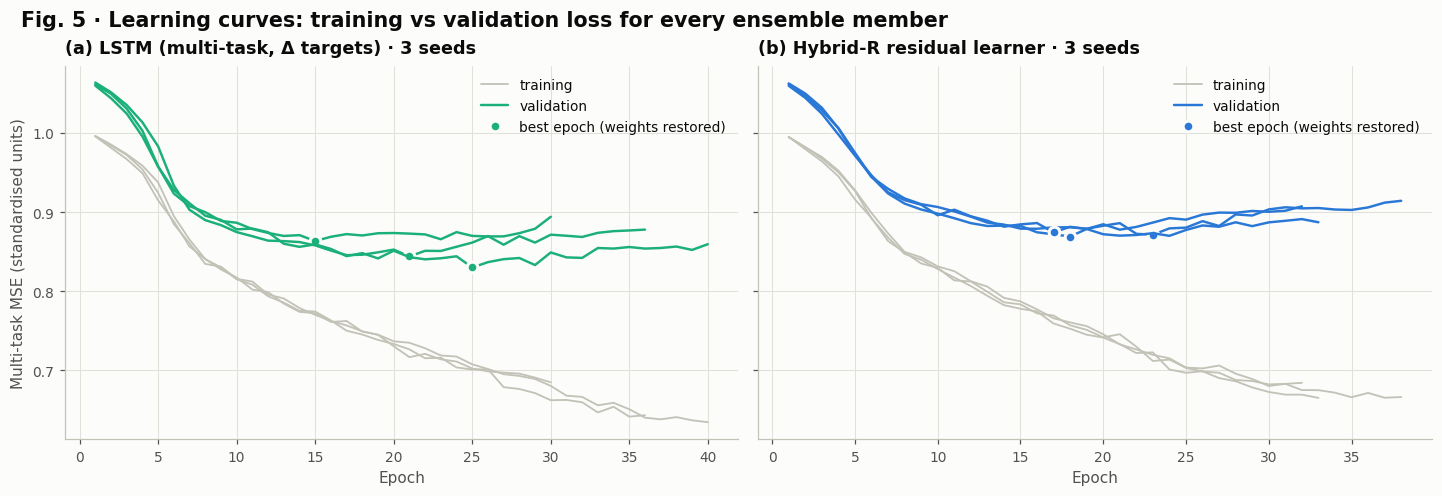

In [22]:
# ── 10.1  Fig. 5 — learning curves of both neural ensembles ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, histories, model_name, title in [
        (axes[0], lstm_histories, "LSTM", "(a) LSTM (multi-task, Δ targets)"),
        (axes[1], residual_histories, "Hybrid-R", "(b) Hybrid-R residual learner")]:
    for k, hist in enumerate(histories):
        epochs = np.arange(1, len(hist["loss"]) + 1)
        best = int(np.argmin(hist["val_loss"]))
        ax.plot(epochs, hist["loss"], color=AXIS, lw=1.2, label="training" if k == 0 else None)
        ax.plot(epochs, hist["val_loss"], color=COLORS[model_name], lw=1.6, label="validation" if k == 0 else None)
        ax.plot(epochs[best], hist["val_loss"][best], "o", ms=7, color=COLORS[model_name], mec=SURFACE, mew=2,
                label="best epoch (weights restored)" if k == 0 else None)
    ax.set_title(f"{title} · {len(histories)} seeds")
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Multi-task MSE (standardised units)")
finish(fig, 5, "Learning curves: training vs validation loss for every ensemble member", "learning_curves")

**Reading Fig. 5.** Training loss keeps falling while validation loss flattens and then rises. Early stopping restores the weights at the validation minimum (the dots), just before the networks begin to memorise the training years. All members converge to similar validation losses, so the ensemble is stable rather than dependent on a lucky seed.

### 10.2 Hybrid-E — optimal per-horizon ensemble
Combining forecasts with error-minimising weights is one of the most robust results in forecasting (Bates & Granger, 1969). For each horizon $h$ a convex weight is estimated **on the validation year**:

$$\hat y^{\,\text{HE}}_{t+h} = w_h\,\hat y^{\,\text{SARIMA}}_{t+h} + (1-w_h)\,\hat y^{\,\text{LSTM}}_{t+h},\qquad
w_h=\operatorname{clip}_{[0,1]}\frac{\sum (\hat y^{L}-y)(\hat y^{L}-\hat y^{S})}{\sum(\hat y^{L}-\hat y^{S})^2},$$

which is the closed-form minimiser of the validation MSE. Where the LSTM is sharper (short leads) it receives more weight. Where it drifts (long leads) the weight moves to SARIMA automatically.

In [23]:
# ── 10.2  Hybrid-E: per-horizon optimal weights on the validation year ───────
def optimal_weights(S, L, Y):
    """Closed-form convex weight on S for every lead (columns), minimising validation MSE."""
    d = L - S
    return np.clip(np.sum((L - Y[:, None]) * d, axis=0) / np.sum(d * d, axis=0), 0.0, 1.0)

W_SARIMA = optimal_weights(FC["SARIMA"]["val"], FC["LSTM"]["val"], Y_VAL)
FC["Hybrid-E"] = {split: W_SARIMA * FC["SARIMA"][split] + (1 - W_SARIMA) * FC["LSTM"][split]
                  for split in ("val", "test", "future")}
print("Weight on SARIMA by horizon: " + ", ".join(f"h={h}: {W_SARIMA[h - 1]:.2f}" for h in (1, 2, 3, 7, 14, 30, H)))
print(f"Hybrid-E day-ahead test RMSE: {metrics(Y_TEST, FC['Hybrid-E']['test'][:, 0])['RMSE (°C)']:.3f} °C")

Weight on SARIMA by horizon: h=1: 0.22, h=2: 0.27, h=3: 0.42, h=7: 0.36, h=14: 1.00, h=30: 1.00, h=90: 1.00
Hybrid-E day-ahead test RMSE: 2.008 °C


## 11 · Evaluation on the untouched test year (2016)

### 11.1 Day-ahead accuracy (h = 1)

In [24]:
# ── 11.1  Table 10 — day-ahead metrics for all seven models ────────────────
day_ahead = pd.DataFrame({name: metrics(Y_TEST, FC[name]["test"][:, 0]) for name in MODEL_ORDER}).T
mse_persistence = day_ahead.loc["Persistence", "RMSE (°C)"] ** 2
day_ahead["Skill vs persistence (%)"] = 100 * (1 - day_ahead["RMSE (°C)"] ** 2 / mse_persistence)
day_ahead.insert(0, "Family", [FAMILY[m] for m in day_ahead.index])
show_table(day_ahead, 10, f"Day-ahead (h = 1) accuracy over all {len(TEST_TARGETS)} days of the test year",
           fmt={"RMSE (°C)": "{:.3f}", "MAE (°C)": "{:.3f}", "MAPE (%)": "{:.3f}", "R²": "{:.4f}",
                "MASE": "{:.3f}", "Skill vs persistence (%)": "{:+.1f}"},
           low=["RMSE (°C)", "MAE (°C)", "MAPE (%)", "MASE"], high=["R²", "Skill vs persistence (%)"])

,Family,RMSE (°C),MAE (°C),MAPE (%),R²,MASE,Skill vs persistence (%)
Persistence,Baseline,2.340,1.769,0.626,0.9062,0.952,+0.0
Climatology,Baseline,3.764,2.934,1.036,0.7573,1.579,-158.7
ARIMA,Statistical,2.226,1.718,0.608,0.9151,0.924,+9.5
SARIMA,Statistical,2.164,1.672,0.591,0.9198,0.900,+14.5
LSTM,Deep learning,2.017,1.566,0.555,0.9303,0.843,+25.7
Hybrid-R,Hybrid,2.033,1.596,0.565,0.9292,0.859,+24.5
Hybrid-E,Hybrid,2.008,1.549,0.549,0.9309,0.834,+26.4


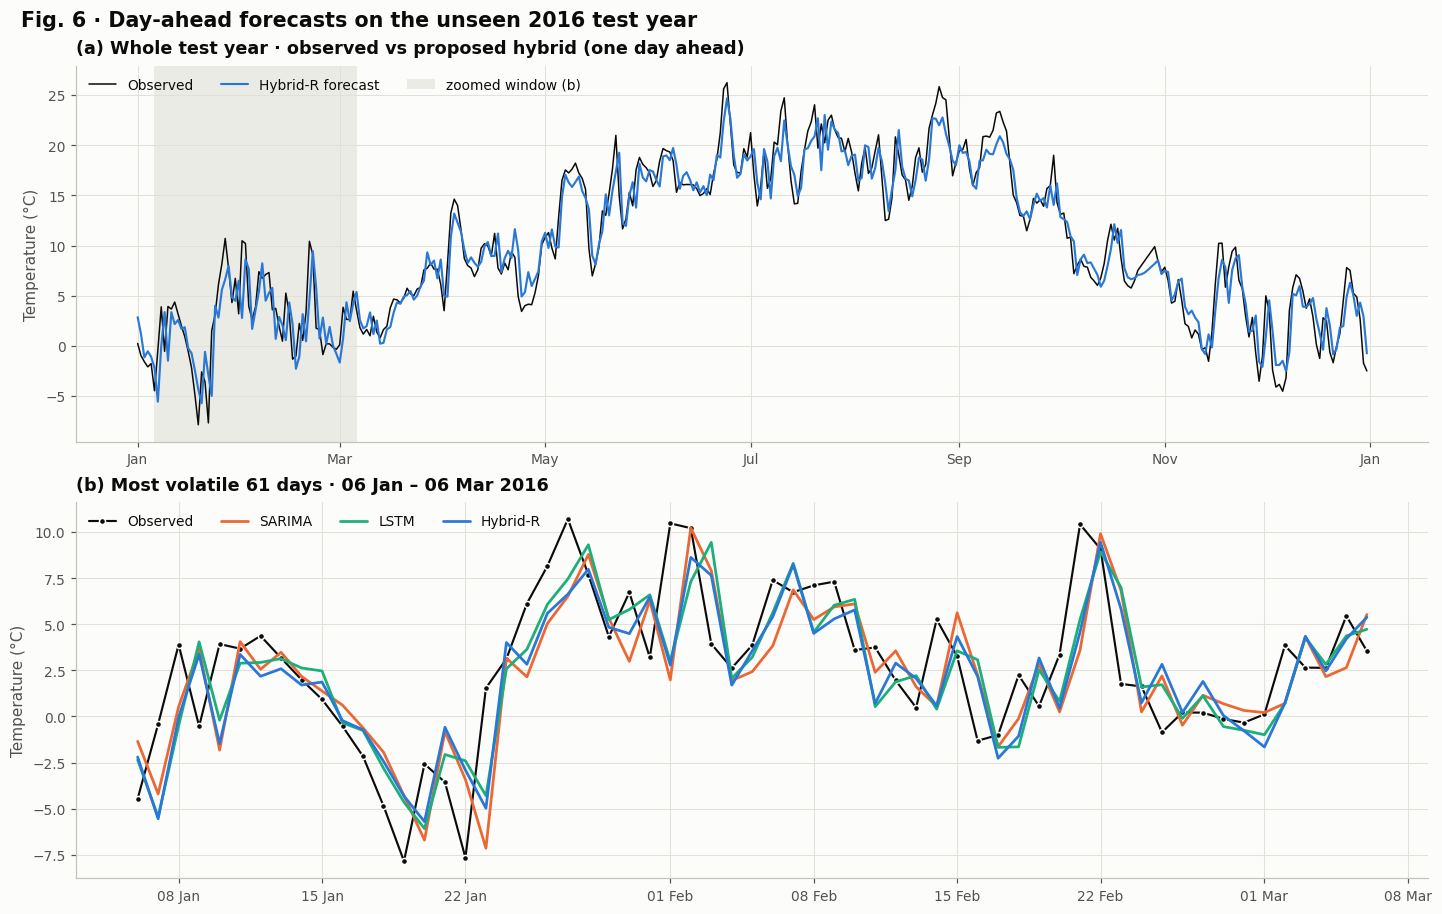

In [25]:
# ── 11.1  Fig. 6 — test-year forecasts against observations ──────────────────
test_dates = y.index[TEST_TARGETS]
actual = Y_TEST
volatility = pd.Series(np.abs(np.diff(actual, prepend=actual[0])), index=test_dates).rolling(61).sum()
zoom_end = volatility.idxmax()
zoom = (test_dates > zoom_end - pd.Timedelta(days=61)) & (test_dates <= zoom_end)

fig, axes = plt.subplots(2, 1, figsize=(13, 8.2))
ax = axes[0]
ax.plot(test_dates, actual, color=INK, lw=1.0, label="Observed")
ax.plot(test_dates, FC["Hybrid-R"]["test"][:, 0], color=COLORS["Hybrid-R"], lw=1.4, label="Hybrid-R forecast")
ax.axvspan(test_dates[zoom][0], test_dates[zoom][-1], color=GRID, alpha=0.6, lw=0, label="zoomed window (b)")
ax.set_title("(a) Whole test year · observed vs proposed hybrid (one day ahead)")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc="upper left", ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax = axes[1]
ax.plot(test_dates[zoom], actual[zoom], color=INK, lw=1.4, marker="o", ms=4, mec=SURFACE, mew=1, label="Observed")
for name in ["SARIMA", "LSTM", "Hybrid-R"]:
    ax.plot(test_dates[zoom], FC[name]["test"][zoom, 0], color=COLORS[name], lw=1.8, label=name)
ax.set_title(f"(b) Most volatile 61 days · {test_dates[zoom][0]:%d %b} – {test_dates[zoom][-1]:%d %b %Y}")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc="upper left", ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
finish(fig, 6, "Day-ahead forecasts on the unseen 2016 test year", "test_forecasts")

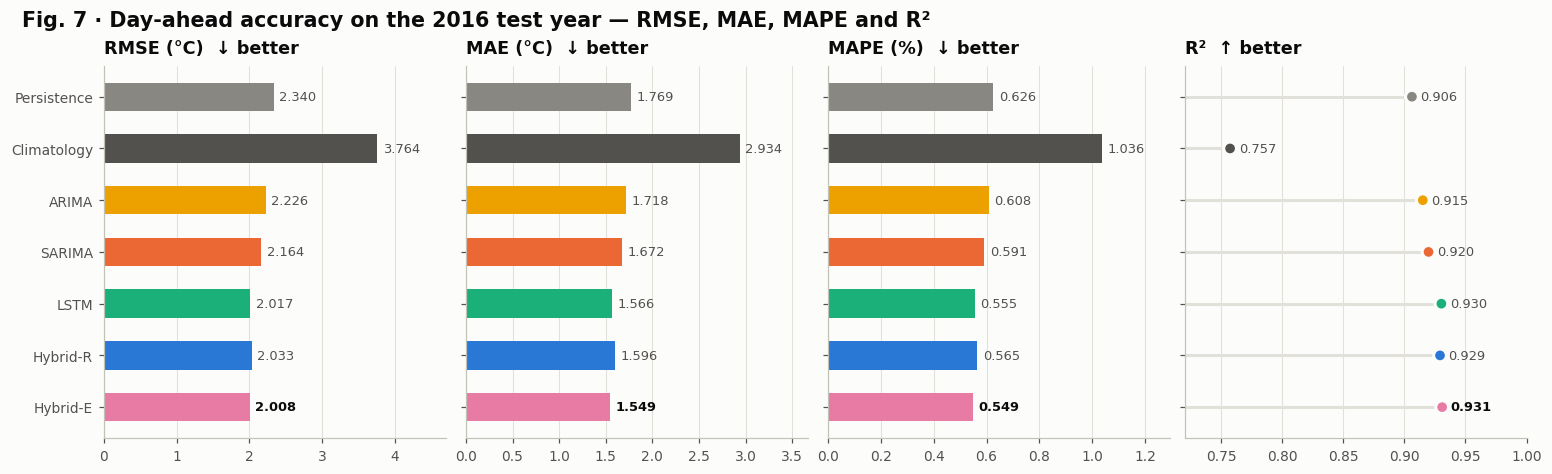

In [26]:
# ── 11.1  Fig. 7 — the four required metrics side by side ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), sharey=True)
order = MODEL_ORDER[::-1]                                # top-to-bottom reading order
ypos = np.arange(len(order))
for ax, metric in zip(axes, ["RMSE (°C)", "MAE (°C)", "MAPE (%)", "R²"]):
    values = day_ahead.loc[order, metric].astype(float).to_numpy()
    if metric == "R²":                                   # R² differences are tiny → dot plot on a zoomed axis
        low_edge = np.floor((values.min() - 0.02) * 50) / 50
        ax.hlines(ypos, low_edge, values, color=GRID, lw=2)
        ax.scatter(values, ypos, s=70, c=[COLORS[m] for m in order], edgecolors=SURFACE, linewidths=2, zorder=3)
        ax.set_xlim(low_edge, 1.0)
    else:
        ax.barh(ypos, values, height=0.55, color=[COLORS[m] for m in order])
        ax.set_xlim(0, values.max() * 1.25)
    best = values.argmax() if metric == "R²" else values.argmin()
    for yi, v in zip(ypos, values):
        ax.text(v + (0.007 if metric == "R²" else values.max() * 0.02), yi, f"{v:.3f}", va="center", fontsize=8.5,
                color=INK if yi == best else INK_2, fontweight="bold" if yi == best else "normal")
    ax.set_title(metric + ("  ↑ better" if metric == "R²" else "  ↓ better"))
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(ypos, order)
finish(fig, 7, "Day-ahead accuracy on the 2016 test year — RMSE, MAE, MAPE and R²", "metric_comparison")

### 11.2 Is the difference real? — Diebold–Mariano tests

Small differences in RMSE can arise by chance. The Diebold–Mariano test (1995), with the Harvey–Leybourne–Newbold (1997) small-sample correction, asks whether two models' squared errors differ *systematically*. Its null hypothesis is equal accuracy. The loss differential $d_t = e^2_{1,t} - e^2_{2,t}$ is tested with a variance estimator that allows for the autocorrelation that multi-step forecast errors always have. A negative statistic means the hybrid is the more accurate model.

In [27]:
# ── 11.2  Table 11 — Diebold–Mariano tests: Hybrid-R against every other model ─
def diebold_mariano(e1, e2, h=1):
    """DM test (squared-error loss) with the HLN correction. Negative statistic ⇒ model 1 more accurate."""
    ok = np.isfinite(e1) & np.isfinite(e2)
    d = e1[ok] ** 2 - e2[ok] ** 2
    T, d_bar = len(d), d.mean()
    autocov = [np.sum((d[k:] - d_bar) * (d[:T - k] - d_bar)) / T for k in range(h)]
    variance = max((autocov[0] + 2 * sum(autocov[1:])) / T, 1e-12)
    statistic = d_bar / np.sqrt(variance) * np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    return statistic, 2 * stats.t.sf(abs(statistic), df=T - 1)

errors = {name: Y_TEST[:, None] - FC[name]["test"] for name in MODEL_ORDER}
rows = {}
for other in [m for m in MODEL_ORDER if m != "Hybrid-R"]:
    row = {}
    for h in (1, 7):
        stat, p = diebold_mariano(errors["Hybrid-R"][:, h - 1], errors[other][:, h - 1], h)
        row[f"DM (h={h})"], row[f"p (h={h})"] = stat, p
    stat, p = row["DM (h=1)"], row["p (h=1)"]
    row["Day-ahead verdict"] = ("Hybrid-R significantly better" if p < 0.05 and stat < 0 else
                                "Hybrid-R significantly worse" if p < 0.05 else "no significant difference")
    rows[other] = row
dm_table = pd.DataFrame(rows).T
show_table(dm_table, 11, "Diebold–Mariano tests of Hybrid-R against every other model (5 % level)",
           fmt={c: ("{:+.2f}" if c.startswith("DM") else "{:.4f}") for c in dm_table.columns if c != "Day-ahead verdict"})

,DM (h=1),p (h=1),DM (h=7),p (h=7),Day-ahead verdict
Persistence,-3.97,0.0001,-5.27,0.0000,Hybrid-R significantly better
Climatology,-9.77,0.0000,-0.34,0.7350,Hybrid-R significantly better
ARIMA,-3.52,0.0005,-2.70,0.0072,Hybrid-R significantly better
SARIMA,-2.68,0.0077,-0.94,0.3498,Hybrid-R significantly better
LSTM,+0.55,0.5848,-2.02,0.0440,no significant difference
Hybrid-E,+1.02,0.3098,-1.30,0.1935,no significant difference


### 11.3 How does skill decay with the forecast horizon?
A model that is excellent tomorrow can be useless next month. The figure below follows every model's error from 1 to $H$ days ahead, always on the same 366 test days. Climatology ignores the forecast origin, so its curve is flat by construction, which is a built-in check that the protocol is consistent. Panel (b) shows the skill of each model relative to SARIMA, and panel (c) shows how both hybrids hand over from the neural network to the statistical model as the lead time grows.

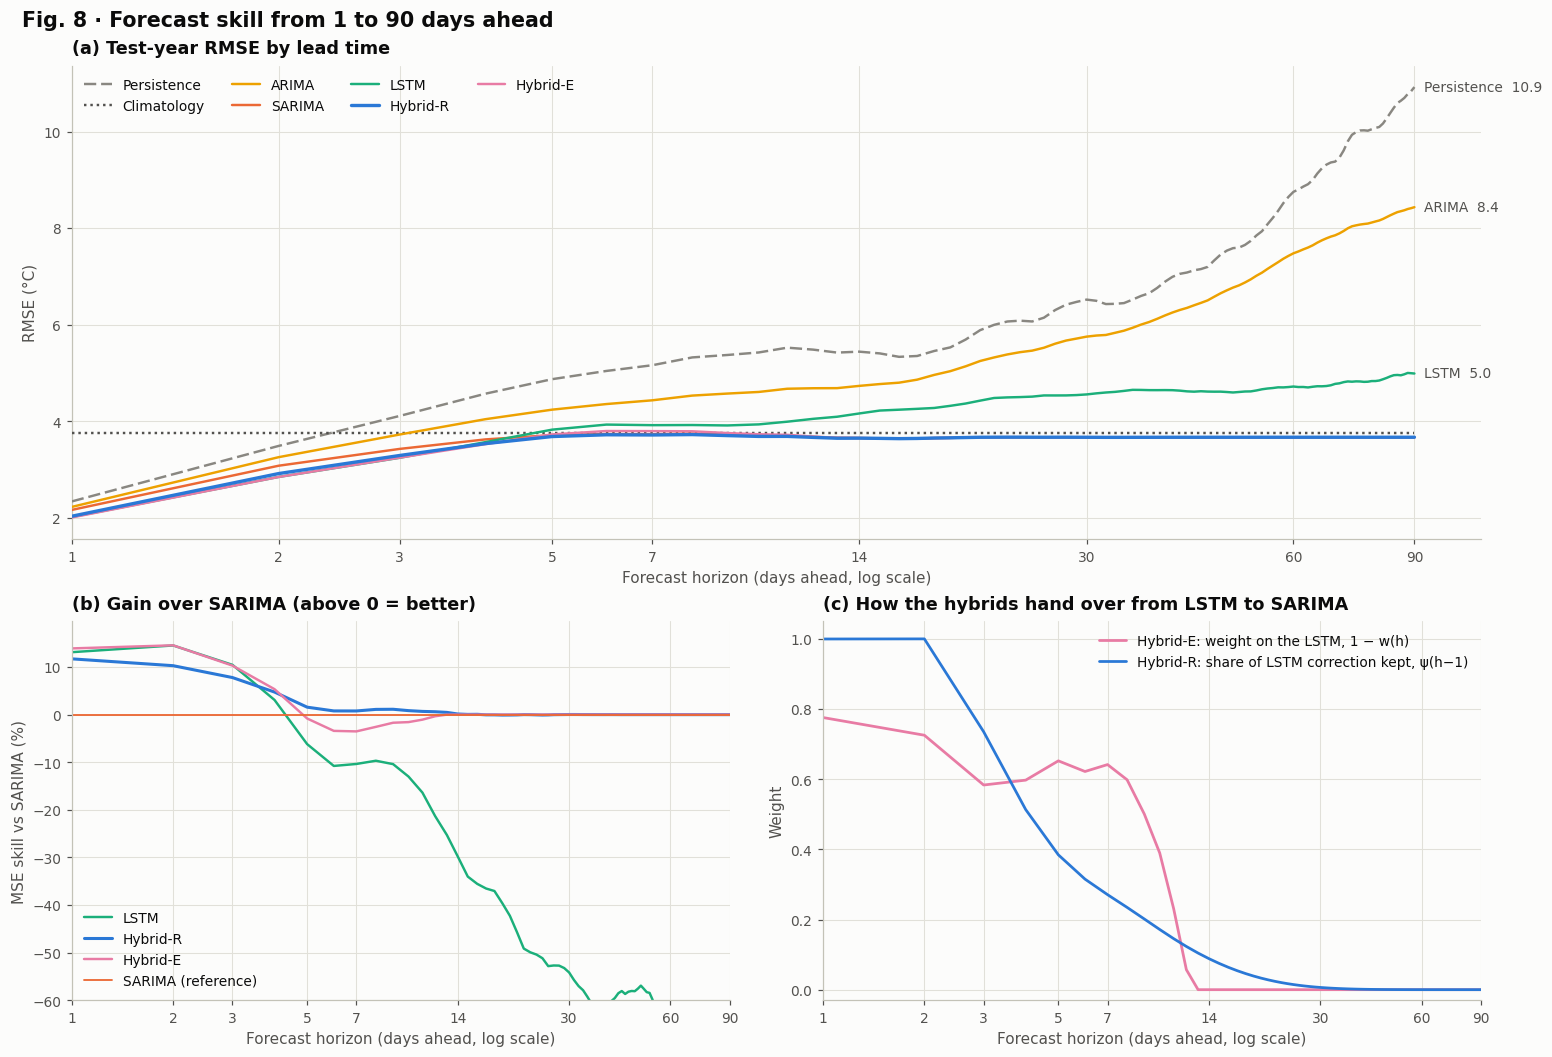

,h = 1,h = 2,h = 3,h = 7,h = 14,h = 30,h = 60,h = 90,Mean 1–90
Persistence,2.34,3.49,4.11,5.16,5.44,6.52,8.75,10.92,7.56
Climatology,3.76,3.76,3.76,3.76,3.76,3.76,3.76,3.76,3.76
ARIMA,2.23,3.26,3.73,4.43,4.73,5.75,7.48,8.43,6.46
SARIMA,2.16,3.08,3.43,3.73,3.65,3.67,3.67,3.67,3.64
LSTM,2.02,2.85,3.24,3.92,4.16,4.56,4.72,4.99,4.52
Hybrid-R,2.03,2.92,3.29,3.72,3.65,3.67,3.67,3.67,3.64
Hybrid-E,2.01,2.85,3.25,3.80,3.65,3.67,3.67,3.67,3.64


In [28]:
# ── 11.3  Fig. 8 and Table 12 — error growth with lead time ────────────────
horizons = np.arange(1, H + 1)

def horizon_axis(ax, right=H):
    """Log-scaled lead-time axis with readable day ticks."""
    ax.set_xscale("log")
    ax.set_xticks([t for t in (1, 2, 3, 5, 7, 14, 30, 60, 90) if t <= H])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(1, right)
    ax.set_xlabel("Forecast horizon (days ahead, log scale)")
rmse_h = pd.DataFrame({name: rmse_by_horizon(FC[name]["test"], Y_TEST) for name in MODEL_ORDER}, index=horizons)

fig = plt.figure(figsize=(14, 9.5))
grid = fig.add_gridspec(2, 2, height_ratios=[1.25, 1])
ax = fig.add_subplot(grid[0, :])
for name in MODEL_ORDER:
    ax.plot(horizons, rmse_h[name], color=COLORS[name], lw=2.2 if name == "Hybrid-R" else 1.6,
            linestyle=LINESTYLES.get(name, "-"), label=name, zorder=4 if name == "Hybrid-R" else 3)
for name in ["Persistence", "ARIMA", "LSTM"]:                       # label only the lines that peel away
    ax.annotate(f"{name}  {rmse_h[name].iloc[-1]:.1f}", (H, rmse_h[name].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=INK_2)
horizon_axis(ax, right=H * 1.25)
ax.set_ylabel("RMSE (°C)")
ax.set_title("(a) Test-year RMSE by lead time")
ax.legend(loc="upper left", ncol=4)

ax = fig.add_subplot(grid[1, 0])
for name in ["LSTM", "Hybrid-R", "Hybrid-E"]:
    skill = 100 * (1 - rmse_h[name] ** 2 / rmse_h["SARIMA"] ** 2)
    ax.plot(horizons, skill, color=COLORS[name], lw=2.0 if name == "Hybrid-R" else 1.6, label=name)
ax.axhline(0, color=COLORS["SARIMA"], lw=1.2, label="SARIMA (reference)")
horizon_axis(ax)
ax.set_ylim(max(-60, ax.get_ylim()[0]), None)
ax.set_ylabel("MSE skill vs SARIMA (%)")
ax.set_title("(b) Gain over SARIMA (above 0 = better)")
ax.legend(loc="lower left")

ax = fig.add_subplot(grid[1, 1])
ax.plot(horizons, 1 - W_SARIMA, color=COLORS["Hybrid-E"], lw=1.8, label="Hybrid-E: weight on the LSTM, 1 − w(h)")
ax.plot(horizons, PSI, color=COLORS["Hybrid-R"], lw=1.8, label="Hybrid-R: share of LSTM correction kept, ψ(h−1)")
horizon_axis(ax)
ax.set_ylim(-0.03, 1.05)
ax.set_ylabel("Weight")
ax.set_title("(c) How the hybrids hand over from LSTM to SARIMA")
ax.legend(loc="upper right")
finish(fig, 8, "Forecast skill from 1 to {} days ahead".format(H), "horizon_analysis")

checkpoints = [h for h in (1, 2, 3, 7, 14, 30, 60, 90) if h <= H]
horizon_table = rmse_h.loc[checkpoints].T
horizon_table.columns = [f"h = {h}" for h in checkpoints]
horizon_table[f"Mean 1–{H}"] = rmse_h.mean()
show_table(horizon_table, 12, "Test-year RMSE (°C) by forecast horizon", fmt="{:.2f}", low=list(horizon_table.columns))

### 11.4 Residual diagnostics
A well-specified forecaster leaves errors that are unbiased, roughly normal and **uncorrelated**; any pattern left in the errors is predictable signal the model missed. The Ljung–Box test checks the first ten autocorrelations of the day-ahead errors jointly, with H₀: *no autocorrelation*.

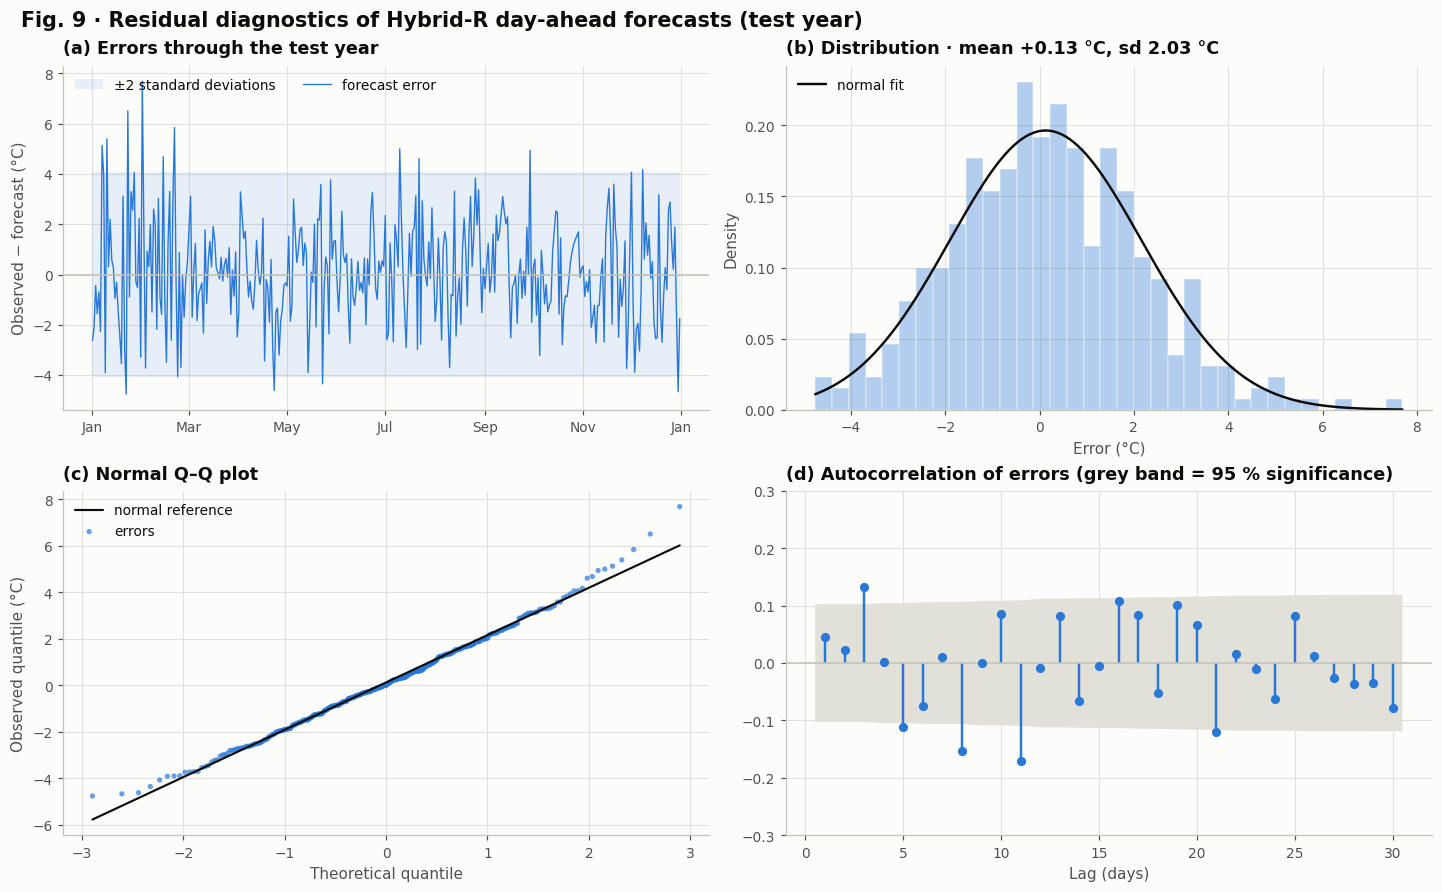

,Bias (°C),Error sd (°C),Skewness,Excess kurtosis,Ljung–Box Q(10),Ljung–Box p
Persistence,-0.009,2.340,+0.21,+0.92,35.7,0.0001
Climatology,+0.821,3.673,+0.27,-0.01,432.0,0.0000
ARIMA,+0.016,2.226,+0.25,+0.64,17.2,0.0695
SARIMA,+0.138,2.160,+0.37,+0.88,19.5,0.0340
LSTM,+0.038,2.017,+0.15,+0.48,25.5,0.0044
Hybrid-R,+0.130,2.029,+0.28,+0.31,26.0,0.0038
Hybrid-E,+0.060,2.007,+0.22,+0.59,24.1,0.0073


In [29]:
# ── 11.4  Fig. 9 and Table 13 — diagnostics of the day-ahead errors ─────────
resid = pd.Series(Y_TEST - FC["Hybrid-R"]["test"][:, 0], index=test_dates)
sd = resid.std()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
ax.fill_between(resid.index, -2 * sd, 2 * sd, color=COLORS["Hybrid-R"], alpha=0.10, lw=0, label="±2 standard deviations")
ax.plot(resid.index, resid, color=COLORS["Hybrid-R"], lw=0.9, label="forecast error")
ax.axhline(0, color=AXIS, lw=1)
ax.set_title("(a) Errors through the test year"); ax.set_ylabel("Observed − forecast (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b")); ax.legend(loc="upper left", ncol=2)

ax = axes[0, 1]
ax.hist(resid, bins=35, density=True, color=COLORS["Hybrid-R"], alpha=0.35, edgecolor=SURFACE, linewidth=1)
grid_x = np.linspace(resid.min(), resid.max(), 300)
ax.plot(grid_x, stats.norm.pdf(grid_x, resid.mean(), sd), color=INK, lw=1.6, label="normal fit")
ax.set_title(f"(b) Distribution · mean {resid.mean():+.2f} °C, sd {sd:.2f} °C")
ax.set_xlabel("Error (°C)"); ax.set_ylabel("Density"); ax.legend(loc="upper left")

ax = axes[1, 0]
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist="norm")
ax.plot(osm, slope * osm + intercept, color=INK, lw=1.4, label="normal reference")
ax.scatter(osm, osr, s=12, color=COLORS["Hybrid-R"], alpha=0.7, edgecolors="none", label="errors")
ax.set_title("(c) Normal Q–Q plot"); ax.set_xlabel("Theoretical quantile"); ax.set_ylabel("Observed quantile (°C)")
ax.legend(loc="upper left")

ax = axes[1, 1]
plot_acf(resid, lags=30, ax=ax, zero=False, vlines_kwargs={"colors": COLORS["Hybrid-R"], "lw": 1.6})
tidy_correlogram(ax, "(d) Autocorrelation of errors (grey band = 95 % significance)", color=COLORS["Hybrid-R"], markersize=5)
ax.set_ylim(-0.3, 0.3)
finish(fig, 9, "Residual diagnostics of Hybrid-R day-ahead forecasts (test year)", "residual_diagnostics")

diag = {}
for name in MODEL_ORDER:
    e = Y_TEST - FC[name]["test"][:, 0]
    lb = acorr_ljungbox(e, lags=[10])
    diag[name] = {"Bias (°C)": e.mean(), "Error sd (°C)": e.std(), "Skewness": stats.skew(e),
                  "Excess kurtosis": stats.kurtosis(e), "Ljung–Box Q(10)": float(lb["lb_stat"].iloc[0]),
                  "Ljung–Box p": float(lb["lb_pvalue"].iloc[0])}
diag = pd.DataFrame(diag).T
show_table(diag, 13, "Day-ahead error diagnostics (test year)",
           fmt={"Bias (°C)": "{:+.3f}", "Error sd (°C)": "{:.3f}", "Skewness": "{:+.2f}", "Excess kurtosis": "{:+.2f}",
                "Ljung–Box Q(10)": "{:.1f}", "Ljung–Box p": "{:.4f}"})

**Reading Fig. 9 and Table 13.** The hybrid's day-ahead errors are centred near zero and close to normal, with slightly heavy tails: the Q–Q points bend away from the line at the extremes. With 366 test days the Ljung–Box test can detect very small autocorrelations. The correlations that remain (Fig. 9d) are far weaker than those left by persistence and climatology, but they show there is still some predictable structure. Multi-day weather regimes are a plausible source and a target for future work.

## 12 · Uncertainty quantification

A forecast without an error bar is incomplete. Two kinds of 95 % prediction interval are used:

* **Analytic intervals (ARIMA, SARIMA).** The state-space model gives the exact forecast variance $\sigma_h^2$ at each horizon, and the interval is $\hat y \pm z_{0.975}\,\sigma_h$ under Gaussian errors.
* **Split-conformal intervals (LSTM and hybrids).** Neural networks have no analytic error variance. Conformal prediction (Vovk et al., 2005) makes no distributional assumption. For each horizon it takes the $\lceil (n+1)(1-\alpha)\rceil$-th smallest absolute error on the **validation year** as the half-width $q_h$, so the interval is $\hat y \pm q_h$.

Both are then judged on the **test year** by their *coverage*, the share of observations that fall inside. A calibrated 95 % interval should contain about 95 % of outcomes: less means it is over-confident, more means it is needlessly wide.

In [30]:
# ── 12.1  Interval half-widths per model and horizon ────────────────────────
Z = stats.norm.ppf(1 - ALPHA / 2)

def conformal_halfwidths(F_val, Y_val):
    """Per-lead split-conformal half-width: the ⌈(n+1)(1−α)⌉-th smallest absolute validation error."""
    errors_abs = np.abs(Y_val[:, None] - F_val)
    level = min(1.0, np.ceil((len(Y_val) + 1) * (1 - ALPHA)) / len(Y_val))
    return np.quantile(errors_abs, level, axis=0, method="higher")

HALF = {"ARIMA": Z * arima_full.get_forecast(H, exog=arima_exog_future).se_mean.to_numpy(),
        "SARIMA": Z * sarima_full.get_forecast(H, exog=sarima_exog.iloc[n:]).se_mean.to_numpy()}
for name in ["LSTM", "Hybrid-R", "Hybrid-E"]:
    HALF[name] = conformal_halfwidths(FC[name]["val"], Y_VAL)

# ── 12.2  Table 14 — coverage and width on the test year ────────────────────
rows = {}
for name, half in HALF.items():
    inside = np.abs(Y_TEST[:, None] - FC[name]["test"]) <= half[None, :]
    rows[name] = {"Method": "analytic (Gaussian)" if name in ("ARIMA", "SARIMA") else "split-conformal",
                  "Coverage h = 1": inside[:, 0].mean() * 100,
                  "Coverage h = 7": inside[:, 6].mean() * 100,
                  "Coverage h = 30": inside[:, 29].mean() * 100,
                  f"Coverage, all {H} horizons": inside.mean() * 100,
                  "Width h = 1 (°C)": 2 * half[0], f"Mean width (°C)": 2 * half.mean()}
coverage_table = pd.DataFrame(rows).T
show_table(coverage_table, 14, f"Calibration of {100 * (1 - ALPHA):.0f} % prediction intervals on the test year",
           fmt={c: ("{}" if c == "Method" else "{:.1f}") for c in coverage_table.columns})

,Method,Coverage h = 1,Coverage h = 7,Coverage h = 30,"Coverage, all 90 horizons",Width h = 1 (°C),Mean width (°C)
ARIMA,analytic (Gaussian),95.4,94.5,98.1,96.8,9.0,25.0
SARIMA,analytic (Gaussian),96.4,96.4,97.3,96.9,8.8,15.9
LSTM,split-conformal,95.1,97.0,97.0,96.8,8.5,20.3
Hybrid-R,split-conformal,96.7,98.1,98.6,98.5,8.8,17.6
Hybrid-E,split-conformal,95.1,97.0,98.6,98.4,8.5,17.6


**Reading Table 14.** Coverage close to 95 % means the intervals can be trusted as stated. Among calibrated models, a **narrower** interval is better: it is equally reliable but more informative. The recursive LSTM's intervals widen sharply with the horizon, which is the uncertainty counterpart of its error accumulation in Fig. 8.

## 13 · 90-day out-of-sample forecast

Finally, every model forecasts the **future** beyond the last observation (31 Dec 2016). Parameters stay frozen as estimated on the training years; the models' states have absorbed every observation up to the forecast origin, exactly as in an operational setting. The forecast window covers the end of winter and the start of spring, so a good forecast must follow the seasonal turn while its uncertainty widens to the climatological spread.

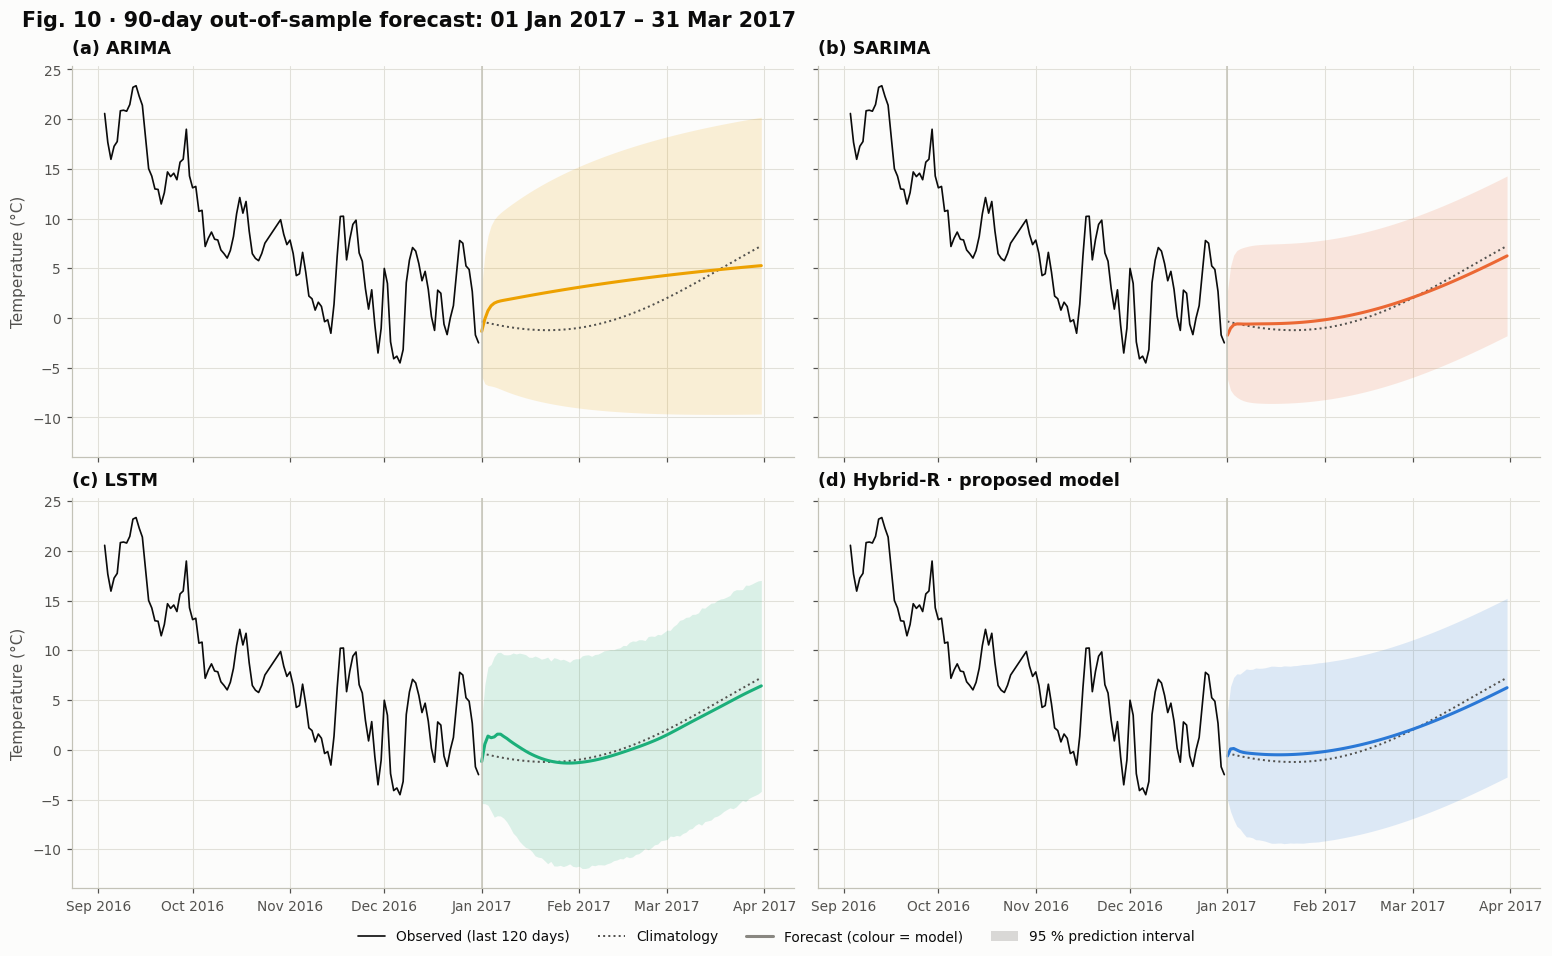

In [31]:
# ── 13.1  Fig. 10 — 90-day outlook with 95 % prediction intervals ───────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

history = y.iloc[-120:]
outlook_models = ["ARIMA", "SARIMA", "LSTM", "Hybrid-R"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8.6), sharex=True, sharey=True)
for panel, (ax, name) in enumerate(zip(axes.flat, outlook_models)):
    forecast, half = FC[name]["future"], HALF[name]
    ax.plot(history.index, history, color=INK, lw=1.1)
    ax.plot(future_index, FC["Climatology"]["future"], color=COLORS["Climatology"], lw=1.3,
            linestyle=LINESTYLES["Climatology"])
    ax.fill_between(future_index, forecast - half, forecast + half, color=COLORS[name], alpha=0.15, lw=0)
    ax.plot(future_index, forecast, color=COLORS[name], lw=2.0)
    ax.axvline(future_index[0], color=AXIS, lw=1)
    ax.set_title(f"({'abcd'[panel]}) {name}" + (" · proposed model" if name == "Hybrid-R" else ""))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
shown = [history.to_numpy()] + [FC[m]["future"] + sign * HALF[m] for m in outlook_models for sign in (-1, 1)]
axes[0, 0].set_ylim(min(map(np.min, shown)) - 2, max(map(np.max, shown)) + 2)
for ax in axes[:, 0]:
    ax.set_ylabel("Temperature (°C)")
legend_handles = [
    Line2D([], [], color=INK, lw=1.1, label="Observed (last 120 days)"),
    Line2D([], [], color=COLORS["Climatology"], lw=1.3, linestyle=LINESTYLES["Climatology"], label="Climatology"),
    Line2D([], [], color=MUTED, lw=2.0, label="Forecast (colour = model)"),
    Patch(facecolor=MUTED, alpha=0.3, label=f"{100 * (1 - ALPHA):.0f} % prediction interval")]
try:                                                     # matplotlib >= 3.7: legend placed outside the panels
    fig.legend(handles=legend_handles, loc="outside lower center", ncol=4)
except (ValueError, TypeError):
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))
finish(fig, 10, f"{H}-day out-of-sample forecast: {future_index[0]:%d %b %Y} – {future_index[-1]:%d %b %Y}",
       "future_forecast")

In [32]:
# ── 13.2  Table 15 — forecast values with intervals at selected lead times ──
future = pd.DataFrame(index=future_index)
future.index.name = "date"
for name in ["ARIMA", "SARIMA", "LSTM", "Hybrid-R", "Hybrid-E"]:
    future[name] = FC[name]["future"]
    future[f"{name} lower"] = FC[name]["future"] - HALF[name]
    future[f"{name} upper"] = FC[name]["future"] + HALF[name]
future["Climatology"] = FC["Climatology"]["future"]

leads = [h for h in (1, 7, 14, 30, 60, 90) if h <= H]
snapshot = pd.DataFrame({
    name: [f"{future[name].iloc[h - 1]:+.1f}  [{future[f'{name} lower'].iloc[h - 1]:+.1f}, "
           f"{future[f'{name} upper'].iloc[h - 1]:+.1f}]" for h in leads]
    for name in ["SARIMA", "Hybrid-R", "Hybrid-E", "LSTM", "ARIMA"]},
    index=[f"Day {h} · {future_index[h - 1]:%d %b %Y}" for h in leads])
snapshot["Climatology"] = [f"{future['Climatology'].iloc[h - 1]:+.1f}" for h in leads]
show_table(snapshot, 15, f"Daily mean temperature forecasts in °C with {100 * (1 - ALPHA):.0f} % intervals", fmt="{}")

,SARIMA,Hybrid-R,Hybrid-E,LSTM,ARIMA,Climatology
Day 1 · 01 Jan 2017,"-1.7 [-6.1, +2.7]","-0.6 [-5.0, +3.8]","-1.3 [-5.5, +2.9]","-1.2 [-5.4, +3.1]","-1.3 [-5.8, +3.2]",-0.3
Day 7 · 07 Jan 2017,"-0.6 [-8.4, +7.2]","-0.3 [-8.7, +8.1]","+0.8 [-7.3, +8.9]","+1.6 [-6.7, +9.8]","+1.7 [-7.2, +10.6]",-0.8
Day 14 · 14 Jan 2017,"-0.6 [-8.6, +7.4]","-0.5 [-9.3, +8.3]","-0.6 [-9.4, +8.3]","+0.1 [-9.5, +9.7]","+2.1 [-7.9, +12.2]",-1.1
Day 30 · 30 Jan 2017,"-0.3 [-8.3, +7.8]","-0.2 [-9.3, +8.8]","-0.3 [-9.3, +8.8]","-1.3 [-11.7, +9.1]","+3.0 [-9.0, +15.0]",-1.1
Day 60 · 01 Mar 2017,"+2.1 [-6.0, +10.1]","+2.1 [-6.9, +11.1]","+2.1 [-6.9, +11.1]","+1.5 [-9.0, +12.0]","+4.3 [-9.6, +18.2]",+2.0
Day 90 · 31 Mar 2017,"+6.3 [-1.8, +14.3]","+6.3 [-2.7, +15.2]","+6.3 [-2.7, +15.2]","+6.4 [-4.2, +17.0]","+5.3 [-9.7, +20.2]",+7.3


## 14 · Research summary

### 14.1 Methodology
1. **Data.** Jena Climate, 2009–2016: 420 551 ten-minute records of 14 variables. A data-quality audit covered duplicates, sentinel codes, physical range checks and coverage-based day flags (Table 1). Wind was converted to vector components, the record was resampled to 2 922 days of 11 variables, and four low-coverage days were time-interpolated.
2. **Diagnostics.** STL decomposition, paired ADF/KPSS tests and ACF/PACF analysis established a stationary series with a strong deterministic annual cycle and short-memory anomalies. This motivated $d = 0$ and Fourier seasonality.
3. **Models.** Persistence and climatology baselines; ARIMA with AIC-selected orders; SARIMA with AIC-selected Fourier harmonics and ARMA errors; a multi-task LSTM ensemble predicting next-day changes of all variables; *Hybrid-R*, a SARIMA plus an LSTM learner of its one-step errors with the correction propagated through SARIMA's impulse response; and *Hybrid-E*, a SARIMA–LSTM combination with per-horizon validation-optimal weights.
4. **Protocol.** The split is chronological: 2009–2014 for training, 2015 for validation and 2016 for testing. Parameters are frozen, and every test day is forecast at every lead from 1 to 90 days from rolling origins. The comparison uses RMSE, MAE, MAPE (kelvin), R², MASE and skill scores, Diebold–Mariano tests, Ljung–Box residual tests, and coverage of analytic and split-conformal 95 % intervals.

### 14.2 Results of this run
The cell below writes the findings from the numbers computed above, so they stay correct if the notebook is re-run or re-configured.

In [33]:
# ── 14.2  Auto-generated results summary ────────────────────────────────────
r = day_ahead
best_day_ahead = r["RMSE (°C)"].astype(float).idxmin()
mean_rmse = horizon_table[f"Mean 1–{H}"].astype(float)
best_overall = mean_rmse.idxmin()
hr, sa, ls = r.loc["Hybrid-R"], r.loc["SARIMA"], r.loc["LSTM"]
gain_vs_sarima = 100 * (1 - hr["RMSE (°C)"] / sa["RMSE (°C)"])
dm_sa, dm_ls, dm_pe = dm_table.loc["SARIMA"], dm_table.loc["LSTM"], dm_table.loc["Persistence"]
ranking = " < ".join(f"{m} ({v:.2f})" for m, v in r["RMSE (°C)"].astype(float).sort_values().items())
lstm_growth = rmse_h["LSTM"].iloc[[0, -1]].to_numpy()
relative = {m: 100 * (rmse_h[m] / rmse_h["SARIMA"] - 1) for m in ("LSTM", "Hybrid-R")}   # + = worse than SARIMA
hr_worst, hr_best, lstm_worst = relative["Hybrid-R"].max(), -relative["Hybrid-R"].min(), relative["LSTM"].max()
hr_vs_sarima = ("is at least as accurate as SARIMA at every lead" if hr_worst < 0.05 else
                f"is never more than {hr_worst:.1f} % less accurate than SARIMA at any lead")
mean_ranking = " < ".join(f"{m} ({v:.3f})" for m, v in mean_rmse.sort_values().items())
top3 = list(mean_rmse.sort_values().index[:3])
spread = (mean_rmse[top3[2]] - mean_rmse[top3[0]]) / mean_rmse[top3[0]]
tie_note = (f" The top three differ by less than 1 %, which is a practical tie: beyond about two weeks all three reduce to the same "
            f"seasonal forecast, so they separate only at short leads." if spread < 0.01 and set(top3) <= {"SARIMA", "Hybrid-R", "Hybrid-E"} else "")
cov_hr = coverage_table.loc["Hybrid-R", f"Coverage, all {H} horizons"]
cov_sa = coverage_table.loc["SARIMA", f"Coverage, all {H} horizons"]
cov_hr_1 = coverage_table.loc["Hybrid-R", "Coverage h = 1"]
cov_sa_1 = coverage_table.loc["SARIMA", "Coverage h = 1"]

def calibration(coverage):
    nominal = 100 * (1 - ALPHA)
    if abs(coverage - nominal) <= 2.5:
        return "well calibrated"
    return "conservative, i.e. wider than necessary" if coverage > nominal else "over-confident, i.e. too narrow"
lstm_worse = rmse_h["LSTM"].to_numpy() > rmse_h["SARIMA"].to_numpy()
if not lstm_worse.any():
    lstm_vs_sarima = "beats SARIMA at every horizon"
elif not lstm_worse[0]:
    lstm_vs_sarima = f"is sharper than SARIMA at the shortest leads but falls behind from day {int(np.argmax(lstm_worse)) + 1}"
else:
    lstm_vs_sarima = "trails SARIMA from the first day"

def significance(row):
    p = row["p (h=1)"]
    return f"p = {p:.3f}, significant at 5 %" if p < 0.05 else f"p = {p:.3f}, not significant at 5 %"

text = f"""
**Day-ahead accuracy (RQ1).** On the unseen test year the day-ahead RMSE ranking is: {ranking} °C.
The residual hybrid **Hybrid-R** reached an RMSE of **{hr['RMSE (°C)']:.3f} °C** (MAE {hr['MAE (°C)']:.3f} °C,
MAPE {hr['MAPE (%)']:.3f} %, R² {hr['R²']:.4f}, MASE {hr['MASE']:.3f}). That is **{gain_vs_sarima:.1f} % lower than SARIMA**
({significance(dm_sa)}) and an MSE skill of **{hr['Skill vs persistence (%)']:+.1f} %** over persistence ({significance(dm_pe)}).
Against the stand-alone LSTM the difference is {hr['RMSE (°C)'] - ls['RMSE (°C)']:+.3f} °C ({significance(dm_ls)}).
The most accurate day-ahead model in this run is **{best_day_ahead}**.

**Behaviour across horizons (RQ2).** The recursive LSTM {lstm_vs_sarima}. Its RMSE grows from {lstm_growth[0]:.2f} °C at
day 1 to {lstm_growth[1]:.2f} °C at day {H}, the error accumulation typical of iterated neural forecasts; at its worst lead it is
{lstm_worst:.0f} % less accurate than SARIMA. ARIMA, which has no seasonal component, drifts to {rmse_h['ARIMA'].iloc[-1]:.2f} °C.
SARIMA and both hybrids level off at about {rmse_h['SARIMA'].iloc[-1]:.2f} °C, close to the error of climatology
({rmse_h['Climatology'].mean():.2f} °C), which is the practical predictability limit for daily temperature without a numerical weather
model. **Hybrid-R {hr_vs_sarima}**, and it is up to {hr_best:.1f} % more accurate at the shortest leads, so the neural
correction helps where it can and does no harm elsewhere. Averaged over all {H} leads the ranking is {mean_ranking}.{tie_note}

**Uncertainty (RQ3).** Hybrid-R's split-conformal intervals contained **{cov_hr_1:.1f} %** of day-ahead outcomes
({calibration(cov_hr_1)}) and {cov_hr:.1f} % across all {H} horizons ({calibration(cov_hr)}), against a nominal
{100 * (1 - ALPHA):.0f} %. SARIMA's analytic Gaussian intervals reached {cov_sa_1:.1f} % and {cov_sa:.1f} % respectively.

**Take-away.** The hybrids keep the LSTM's short-range sharpness and SARIMA's long-range stability, the two properties
no single component offers alone. This is the core argument for hybrid statistical–neural forecasting.
"""
display(Markdown(text))


**Day-ahead accuracy (RQ1).** On the unseen test year the day-ahead RMSE ranking is: Hybrid-E (2.01) < LSTM (2.02) < Hybrid-R (2.03) < SARIMA (2.16) < ARIMA (2.23) < Persistence (2.34) < Climatology (3.76) °C.
The residual hybrid **Hybrid-R** reached an RMSE of **2.033 °C** (MAE 1.596 °C,
MAPE 0.565 %, R² 0.9292, MASE 0.859). That is **6.0 % lower than SARIMA**
(p = 0.008, significant at 5 %) and an MSE skill of **+24.5 %** over persistence (p = 0.000, significant at 5 %).
Against the stand-alone LSTM the difference is +0.016 °C (p = 0.585, not significant at 5 %).
The most accurate day-ahead model in this run is **Hybrid-E**.

**Behaviour across horizons (RQ2).** The recursive LSTM is sharper than SARIMA at the shortest leads but falls behind from day 5. Its RMSE grows from 2.02 °C at
day 1 to 4.99 °C at day 90, the error accumulation typical of iterated neural forecasts; at its worst lead it is
36 % less accurate than SARIMA. ARIMA, which has no seasonal component, drifts to 8.43 °C.
SARIMA and both hybrids level off at about 3.67 °C, close to the error of climatology
(3.76 °C), which is the practical predictability limit for daily temperature without a numerical weather
model. **Hybrid-R is at least as accurate as SARIMA at every lead**, and it is up to 6.0 % more accurate at the shortest leads, so the neural
correction helps where it can and does no harm elsewhere. Averaged over all 90 leads the ranking is Hybrid-R (3.638) < Hybrid-E (3.641) < SARIMA (3.645) < Climatology (3.764) < LSTM (4.516) < ARIMA (6.464) < Persistence (7.557). The top three differ by less than 1 %, which is a practical tie: beyond about two weeks all three reduce to the same seasonal forecast, so they separate only at short leads.

**Uncertainty (RQ3).** Hybrid-R's split-conformal intervals contained **96.7 %** of day-ahead outcomes
(well calibrated) and 98.5 % across all 90 horizons (conservative, i.e. wider than necessary), against a nominal
95 %. SARIMA's analytic Gaussian intervals reached 96.4 % and 96.9 % respectively.

**Take-away.** The hybrids keep the LSTM's short-range sharpness and SARIMA's long-range stability, the two properties
no single component offers alone. This is the core argument for hybrid statistical–neural forecasting.


### 14.3 Contributions
1. **A leakage-free, multi-horizon benchmark.** Seven models evaluated under one rolling-origin protocol in which every lead time from 1 to 90 days is scored on the same 366 test days, with naïve baselines, scale-free skill scores and significance tests. These elements are often missing from applied forecasting comparisons (Hewamalage et al., 2023).
2. **Exact vectorised state-space forecasting.** Multi-step ARIMA/SARIMA forecasts from *every* origin come from a single Kalman-filter pass, verified to machine precision against statsmodels. This makes rolling-origin evaluation of statistical models practical.
3. **A stabilised residual hybrid.** Two additions improve Zhang's (2003) hybrid: (i) *multi-task auxiliary targets*, which give the residual network a dense learning signal even though SARIMA's errors are nearly white noise; and (ii) *ψ-weight propagation*, which carries the neural correction forward with SARIMA's own impulse response. The result is a hybrid that does not drift at long horizons.
4. **Calibrated uncertainty for neural forecasts.** Horizon-specific split-conformal intervals give distribution-free 95 % intervals for the LSTM and the hybrids, validated by coverage on unseen data.
5. **A physically sound pipeline.** Kelvin-scale MAPE, vector-averaged wind, coverage-based imputation and two-sided STL kept out of model inputs.

### 14.4 Limitations
* **One station, one test year.** The conclusions concern a single mid-latitude site. A multi-year rolling test would tighten the confidence intervals of the comparison.
* **Imputed days.** Four days in late October 2016 (about 1 % of the test year) had too few readings and were time-interpolated. They remain in the evaluation as targets.
* **Frozen parameters.** Models are not re-estimated during the test year. Periodic refitting could help in a changing climate.
* **No numerical weather prediction inputs.** Beyond about a week, statistical models cannot outperform climatology. Operational skill at those leads requires NWP ensembles.
* **Conformal validity assumes exchangeability**, which serially correlated errors only approximate. The validation year also serves early stopping and the ensemble weights. Coverage is therefore checked empirically on the test year, and a separate calibration year would make the guarantee exact.

### 14.5 Future work
* Feed NWP forecasts (for example ECMWF) as exogenous inputs, and forecast several variables jointly (precipitation, wind).
* Replace the recursive LSTM with sequence-to-sequence, Temporal Fusion Transformer or N-BEATS architectures. Compare against foundation models for time series.
* Extend to multiple stations (graph neural networks) and to Indian climate data (IMD, ERA5), where the monsoon adds a second seasonal regime.
* Use adaptive conformal inference for coverage guarantees under distribution shift.

### 14.6 References
1. Bates, J. M., & Granger, C. W. J. (1969). The combination of forecasts. *Operational Research Quarterly*, 20(4), 451–468.
2. Box, G. E. P., & Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control*. Holden-Day.
3. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning. (Jena Climate dataset)
4. Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, 6(1), 3–73.
5. Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association*, 74(366), 427–431.
6. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263.
7. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291.
8. Hewamalage, H., Ackermann, K., & Bergmeir, C. (2023). Forecast evaluation for data scientists: common pitfalls and best practices. *Data Mining and Knowledge Discovery*, 37(2), 788–832.
9. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
10. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. https://otexts.com/fpp3/
11. Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688.
12. Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics*, 54(1–3), 159–178.
13. Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. *Advances in Neural Information Processing Systems*, 30.
14. Vovk, V., Gammerman, A., & Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
15. Wang, X., Smith, K., & Hyndman, R. (2006). Characteristic-based clustering for time series data. *Data Mining and Knowledge Discovery*, 13(3), 335–364.
16. Zhang, G. P. (2003). Time series forecasting using a hybrid ARIMA and neural network model. *Neurocomputing*, 50, 159–175.

## 15 · Export
All figures (300 dpi), tables (CSV), test-set predictions, the 90-day forecast and the trained networks are written to `outputs/` and bundled into `outputs.zip`. In Colab, open the *Files* panel on the left to download it.

In [34]:
# ── 15.1  Save tables, forecasts, models and the run configuration ─────────
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
tables = {"table01_data_quality": quality, "table03_stationarity": stationarity_table,
          "table05_arima_search": arima_search.drop(columns="result"),
          "table08_sarima_search": sarima_search.drop(columns="result"), "table10_day_ahead_metrics": day_ahead,
          "table11_diebold_mariano": dm_table, "table12_rmse_by_horizon": horizon_table,
          "table13_error_diagnostics": diag, "table14_interval_coverage": coverage_table,
          "future_forecast_90d": future}
for name, table in tables.items():
    table.to_csv(OUT_DIR / f"{name}.csv")

predictions = pd.DataFrame({"observed": Y_TEST, **{m: FC[m]["test"][:, 0] for m in MODEL_ORDER}},
                           index=pd.Index(test_dates, name="date"))
predictions.to_csv(OUT_DIR / "test_day_ahead_predictions.csv")
for k, model in enumerate(lstm_members, start=1):
    model.save(OUT_DIR / "models" / f"lstm_member{k}.keras")
for k, model in enumerate(residual_members, start=1):
    model.save(OUT_DIR / "models" / f"hybrid_residual_member{k}.keras")

config = {"seed": SEED, "train_end": TRAIN_END, "val_end": VAL_END, "forecast_horizon": H, "lookback": LOOKBACK,
          "n_ensemble": N_ENSEMBLE, "batch_size": BATCH_SIZE, "alpha": ALPHA, "arima_order": ARIMA_ORDER,
          "sarima_order": SARIMA_ORDER, "fourier_pairs": K_BEST,
          "versions": {"numpy": np.__version__, "pandas": pd.__version__, "statsmodels": statsmodels.__version__,
                       "tensorflow": tf.__version__}}
(OUT_DIR / "run_config.json").write_text(json.dumps(config, indent=2))
shutil.make_archive("outputs", "zip", OUT_DIR)

files = sorted(p for p in OUT_DIR.rglob("*") if p.is_file())
print(f"{len(files)} files written to {OUT_DIR.as_posix()}/  ·  bundle: outputs.zip "
      f"({Path('outputs.zip').stat().st_size / 1e6:.1f} MB)")
print(f"Total notebook runtime: {(time.time() - NOTEBOOK_START) / 60:.1f} min")

28 files written to outputs/  ·  bundle: outputs.zip (8.1 MB)
Total notebook runtime: 5.3 min


---
*End of notebook.* To reproduce the results exactly, keep `SEED = 42`. Results on a GPU can differ in the last decimal places because cuDNN kernels are non-deterministic. To cite the dataset, credit the weather station of the Max Planck Institute for Biogeochemistry, Jena, as distributed with TensorFlow/Keras.